In [1]:
import math
import pandas as pd
from ImpararePackage import dataRequest
from ImpararePackage import maestro

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report, precision_recall_curve

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn import tree

import numpy as np

import joblib

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# Dataset com label

In [2]:
query = """
    select 
        pa."caso infeccao",
        -- pa."caso infeccao hospitalar",
        -- pa."Conjuntivite",
        -- pa."Infecção da cavidade oral",
        -- pa."Infecção de pele",
        -- pa."Meningite",
        -- pa.comunitaria,
        -- pa.enterocolite,
        -- pa.ipcs,
        -- pa.isc,
        -- pa.pav,
        dtf.*
    from imparare2_dataset_label_full dtf
    inner join new_avaliacao_padrao_ouro pa
        on dtf."registro" = pa.registro 
            and dtf."dia_parsed" = pa.dt_infeccao
                    and dtf.idade_anos <= 1
"""

df = dataRequest.get_data(queryText= query, chunck= None)

# Vendo distribuição variaveis com Label

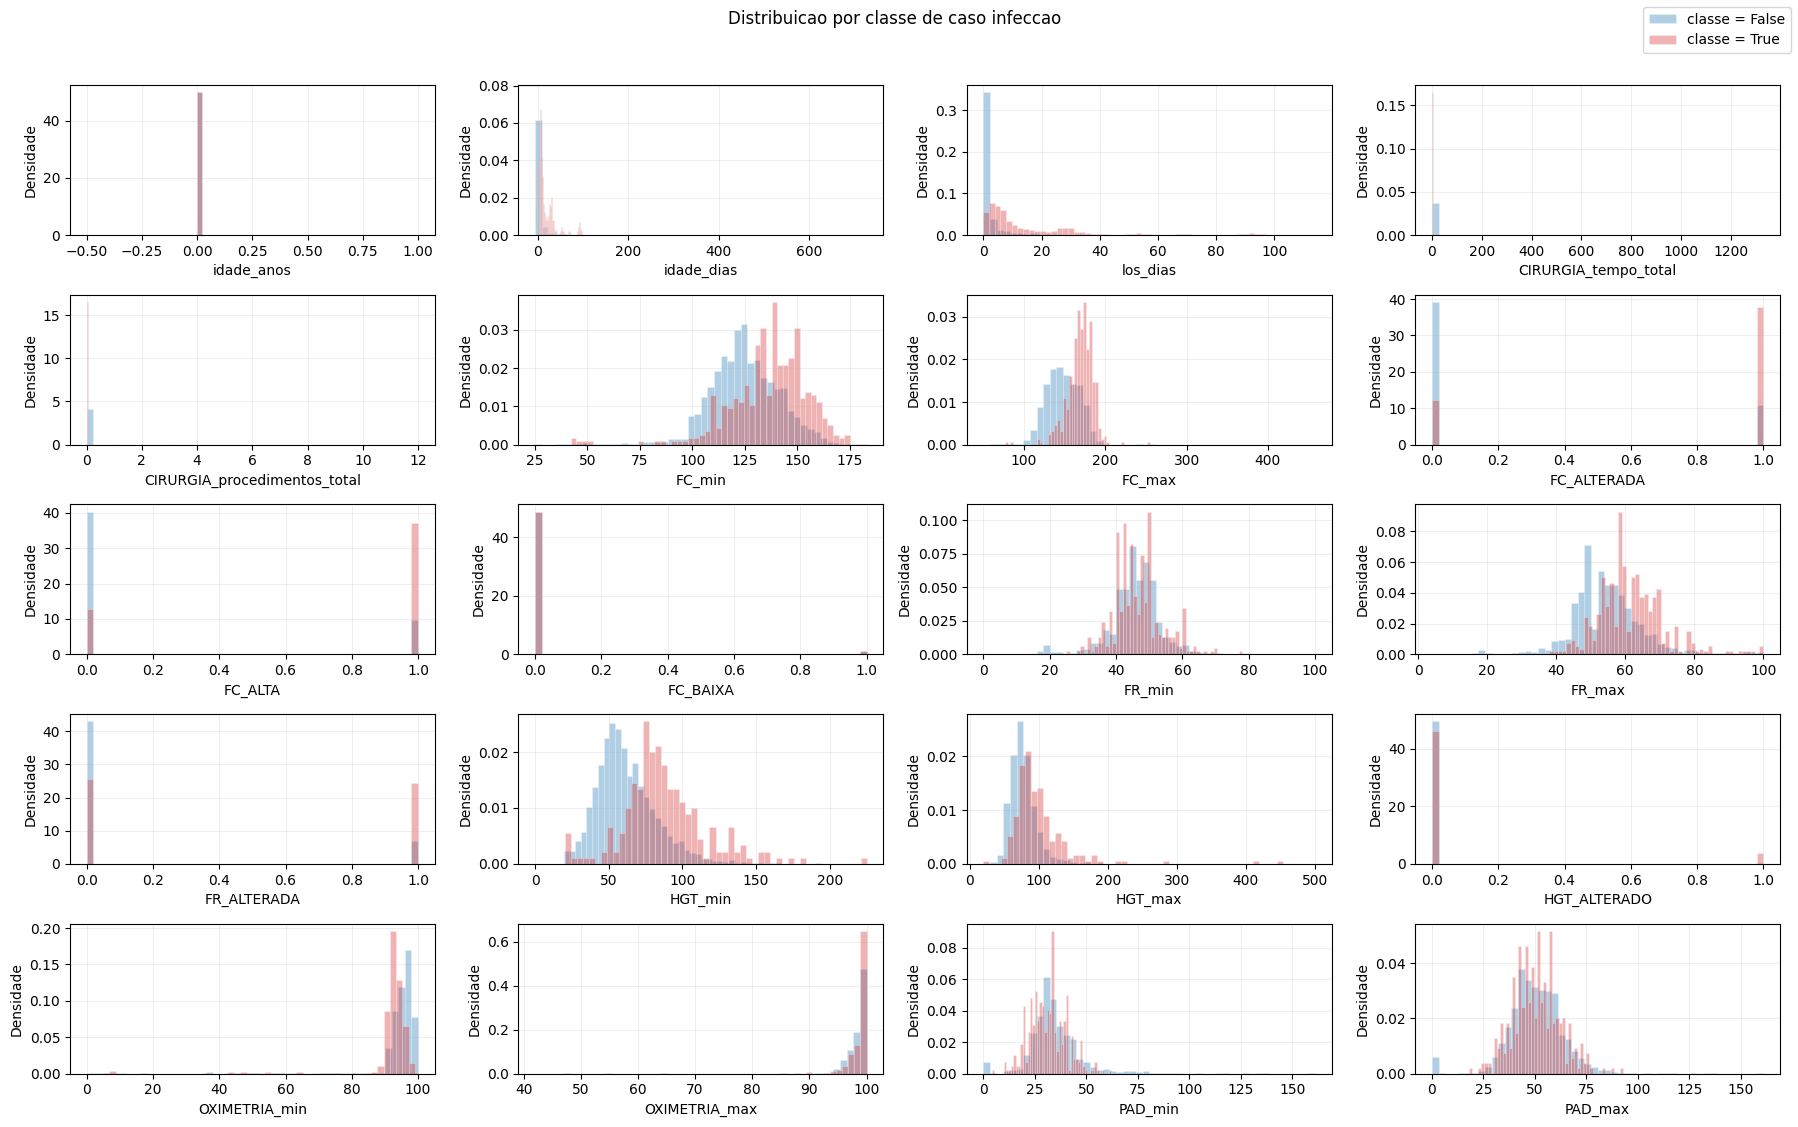

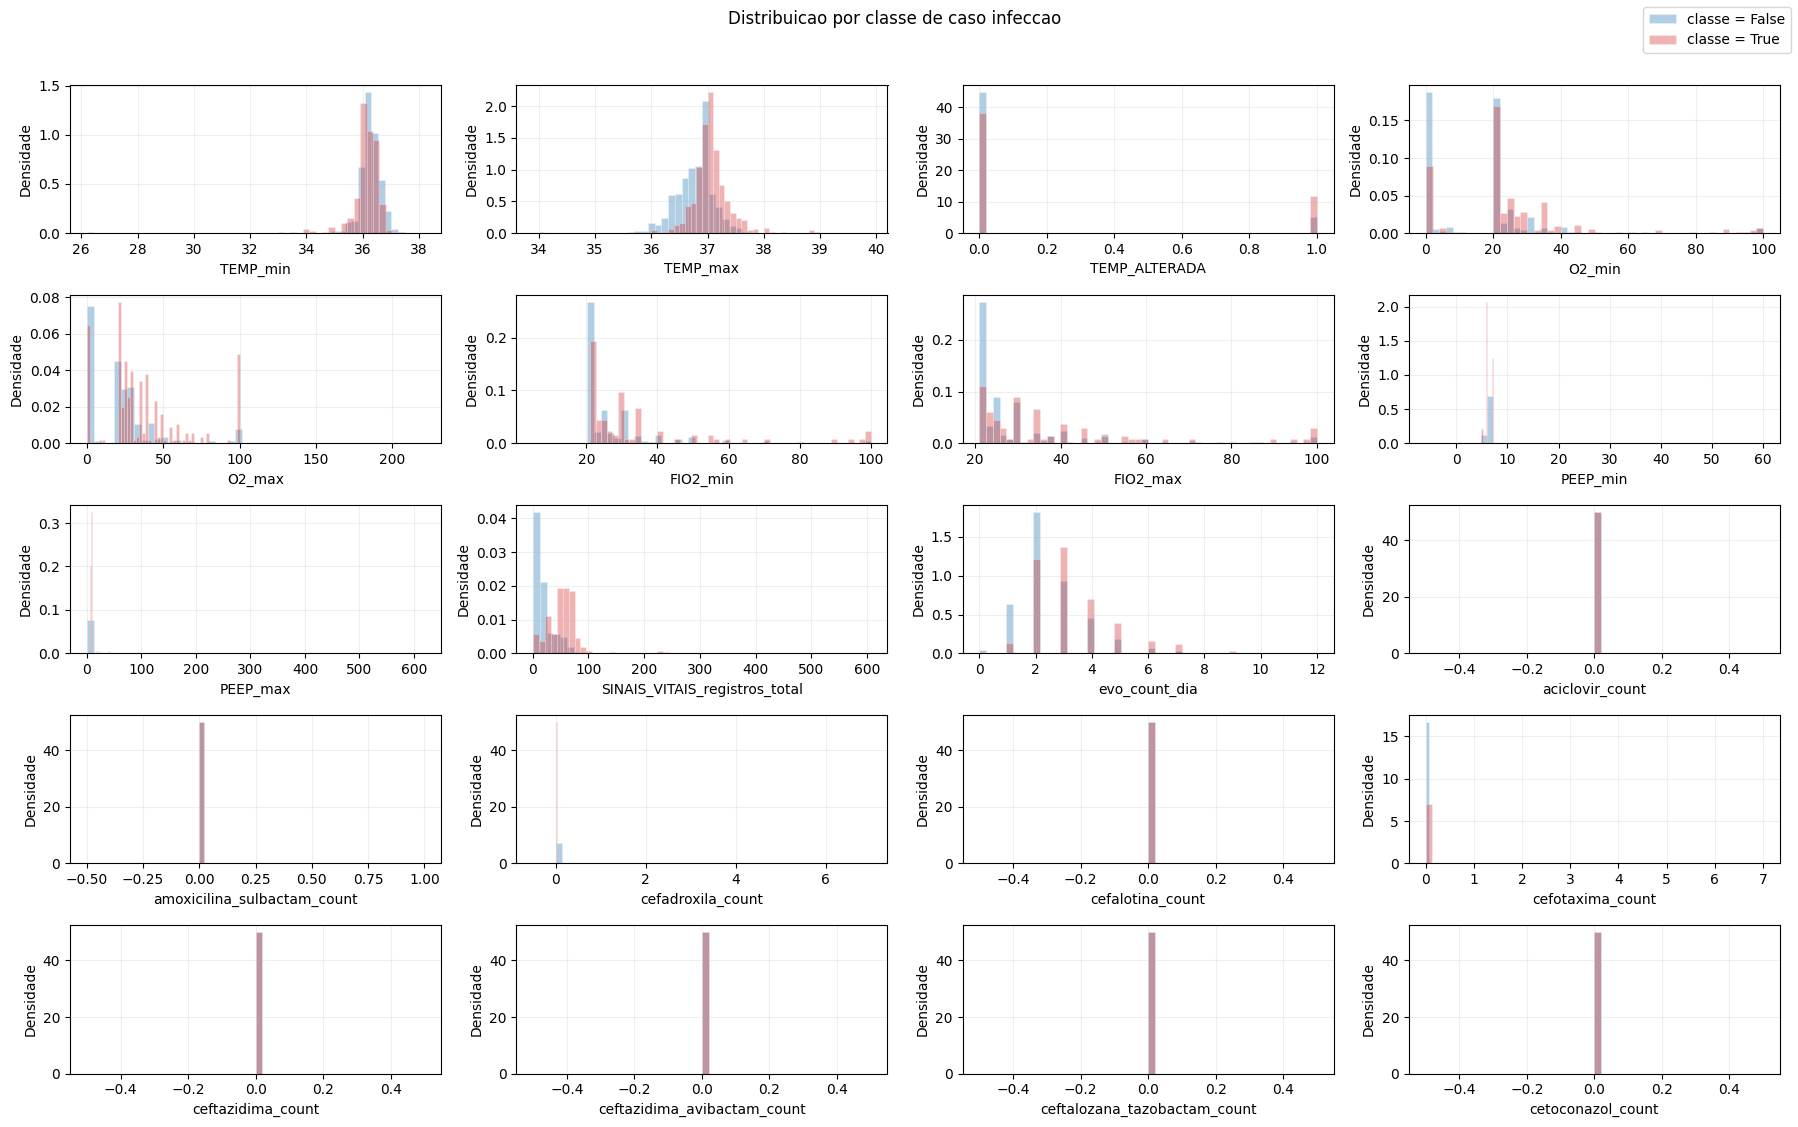

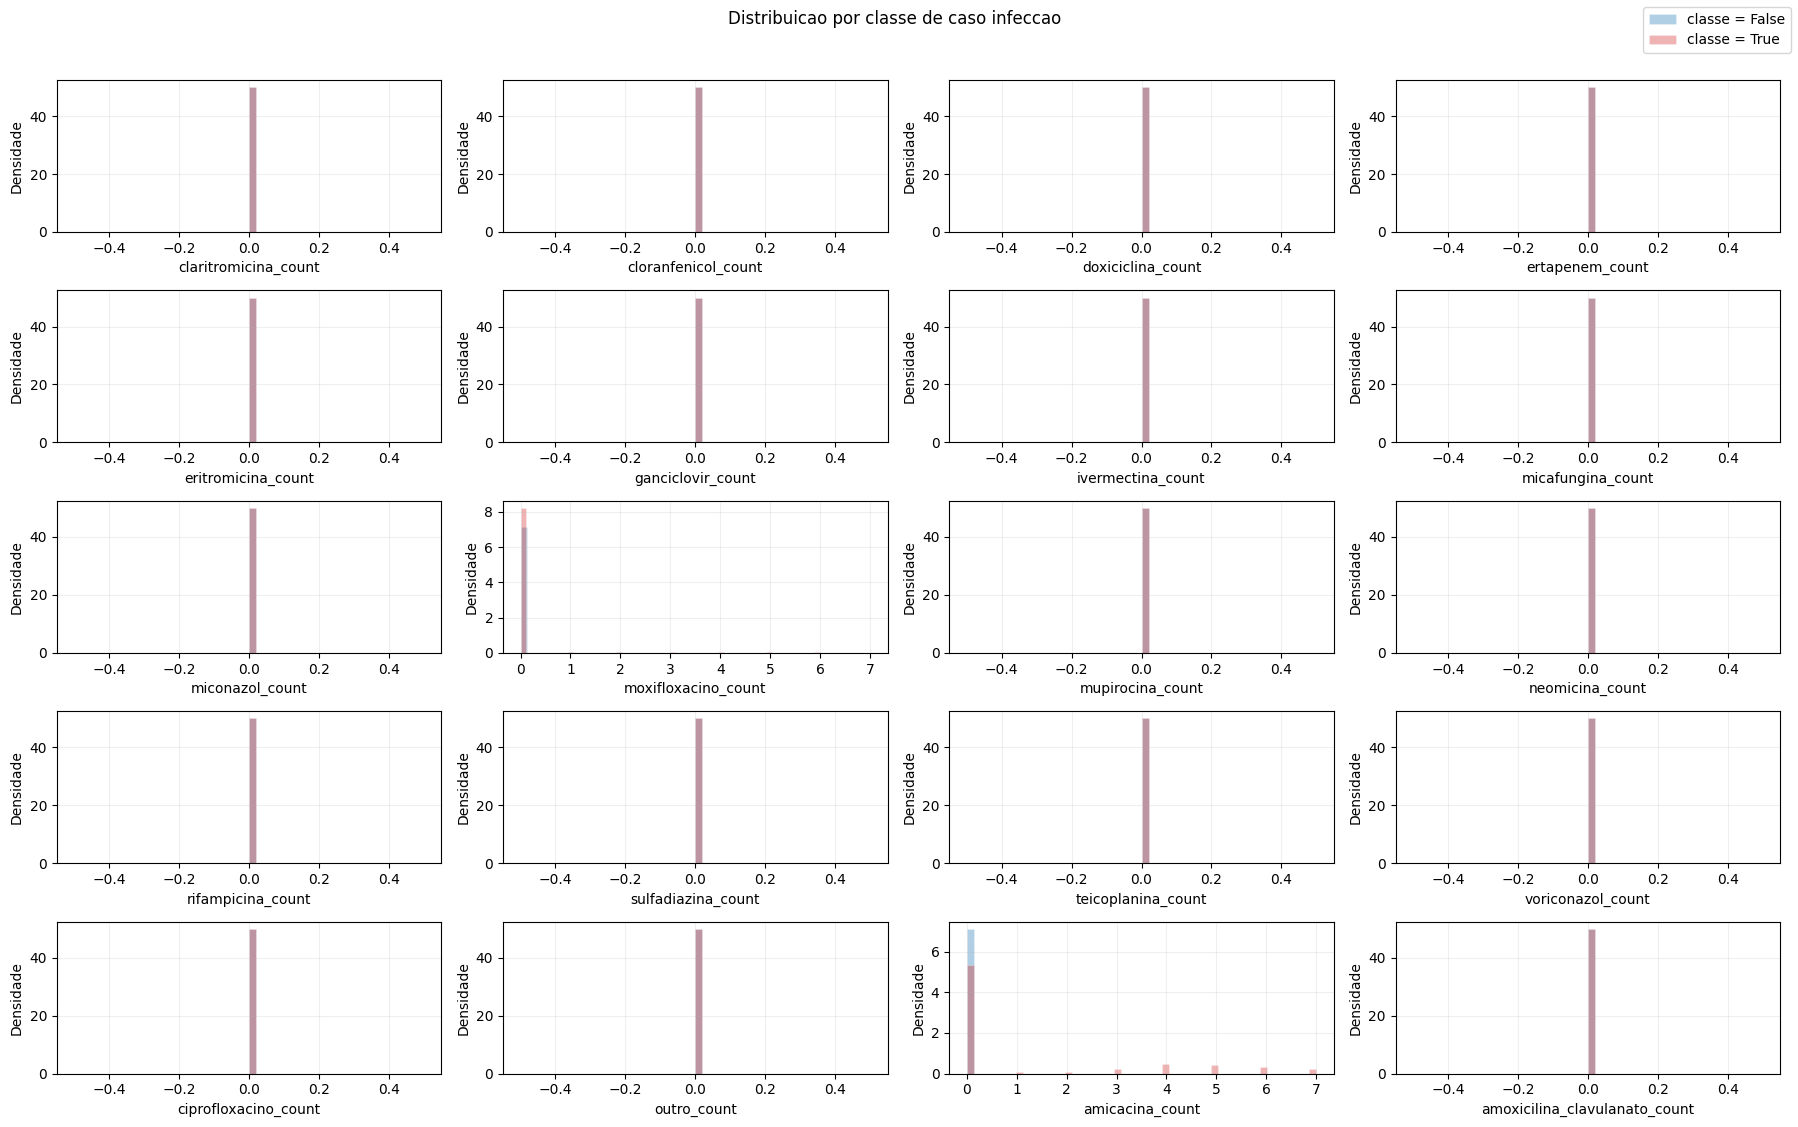

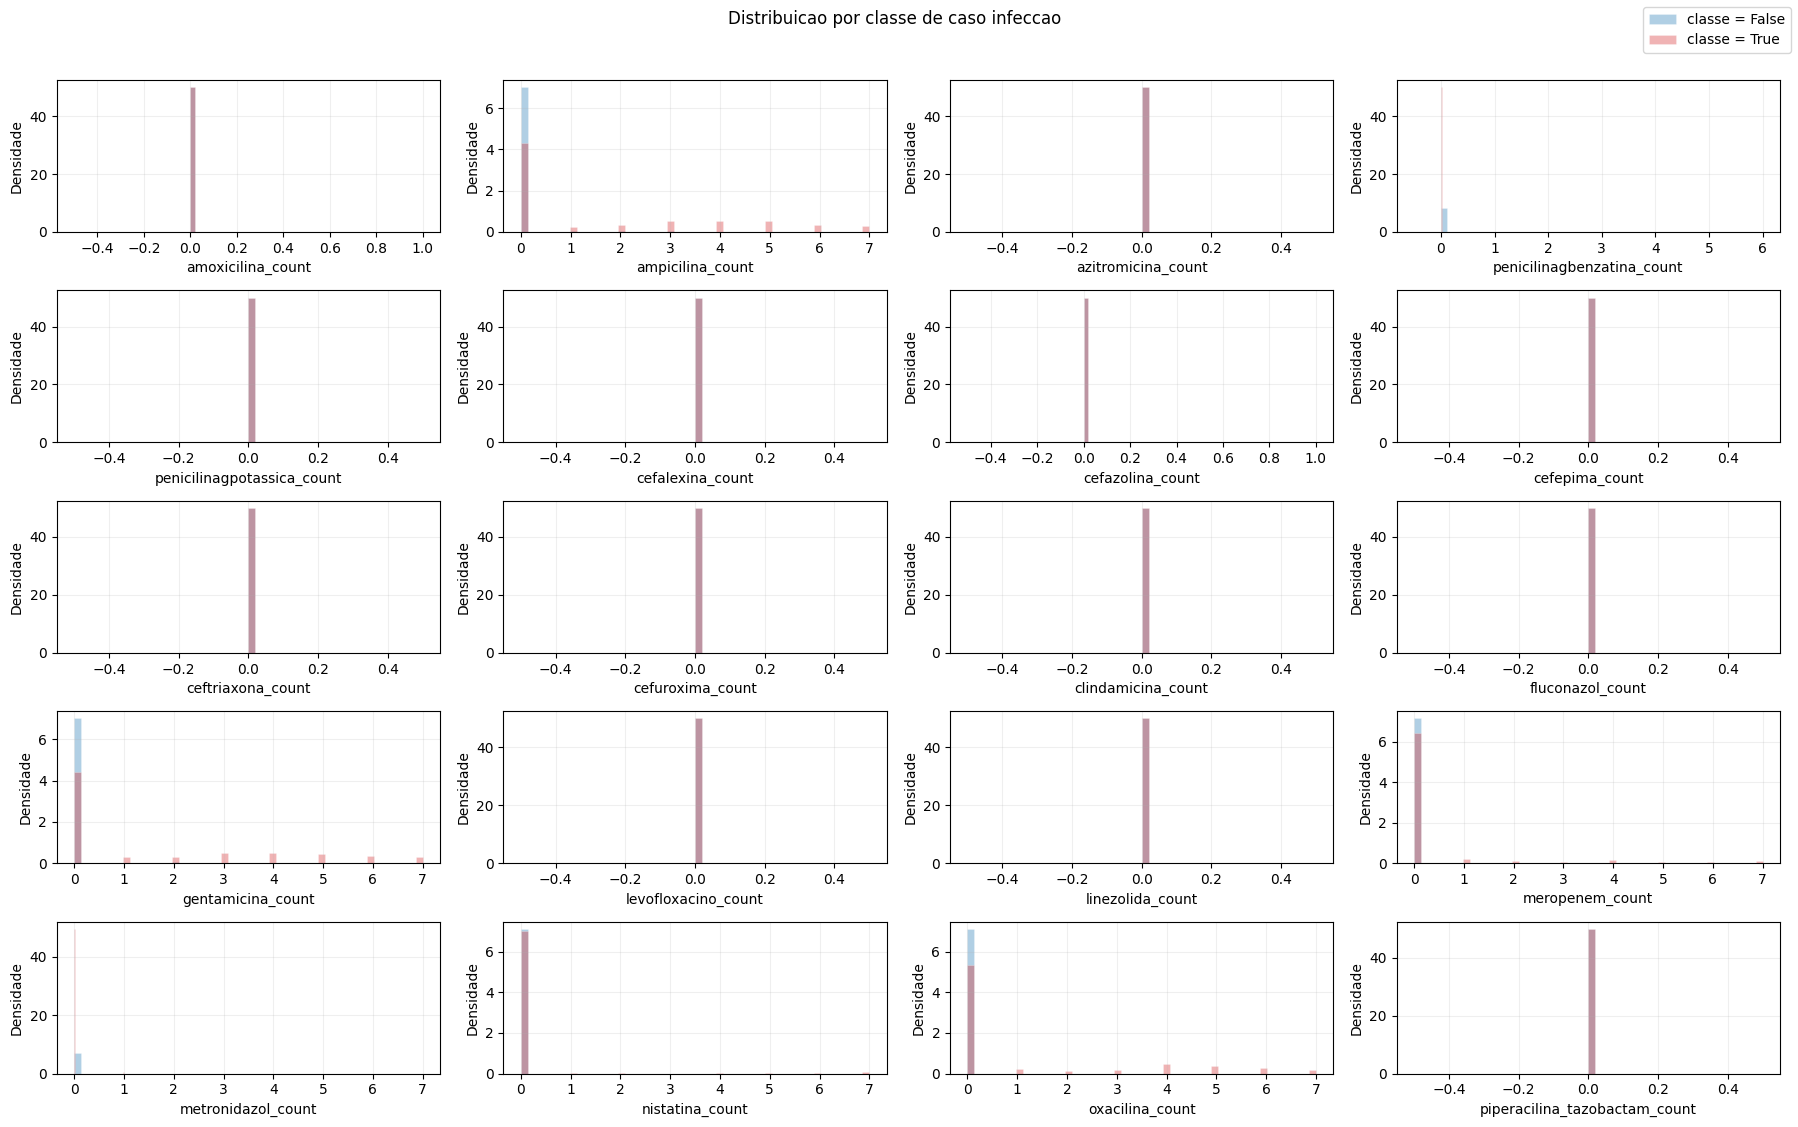

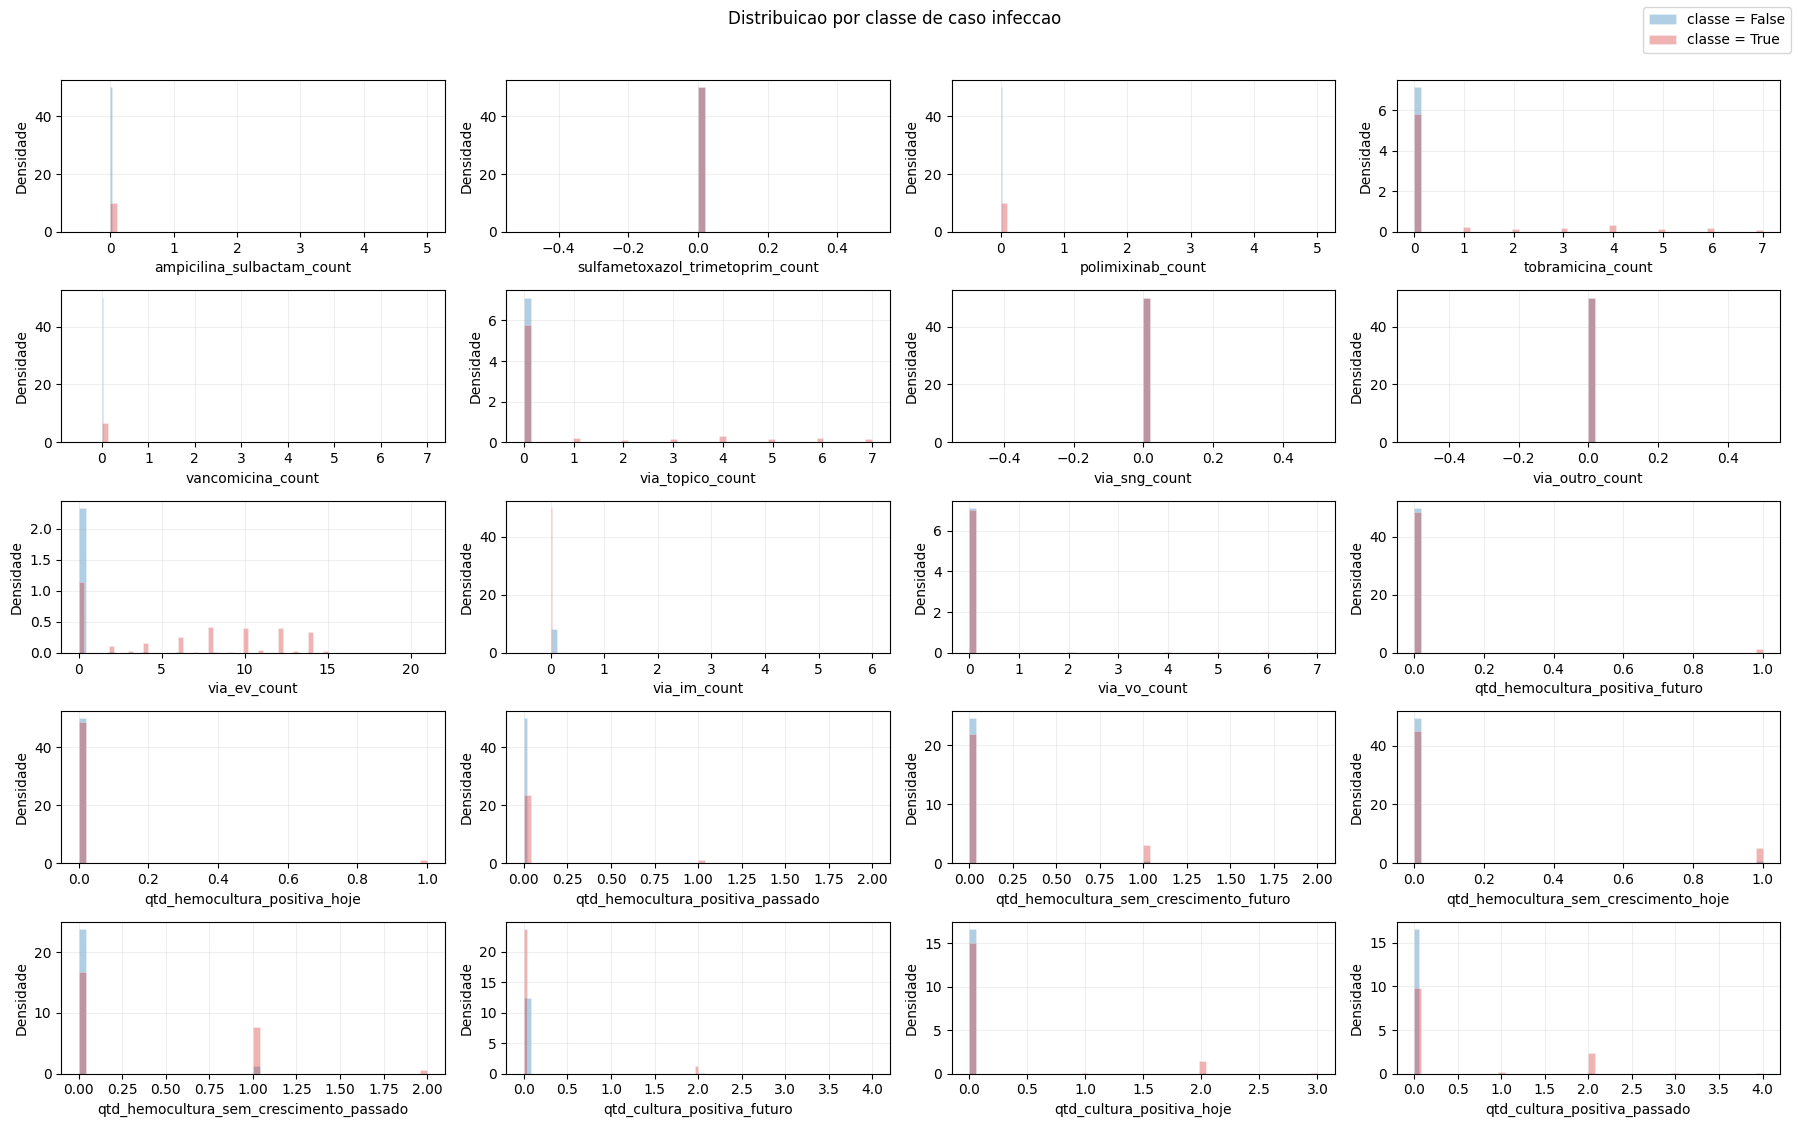

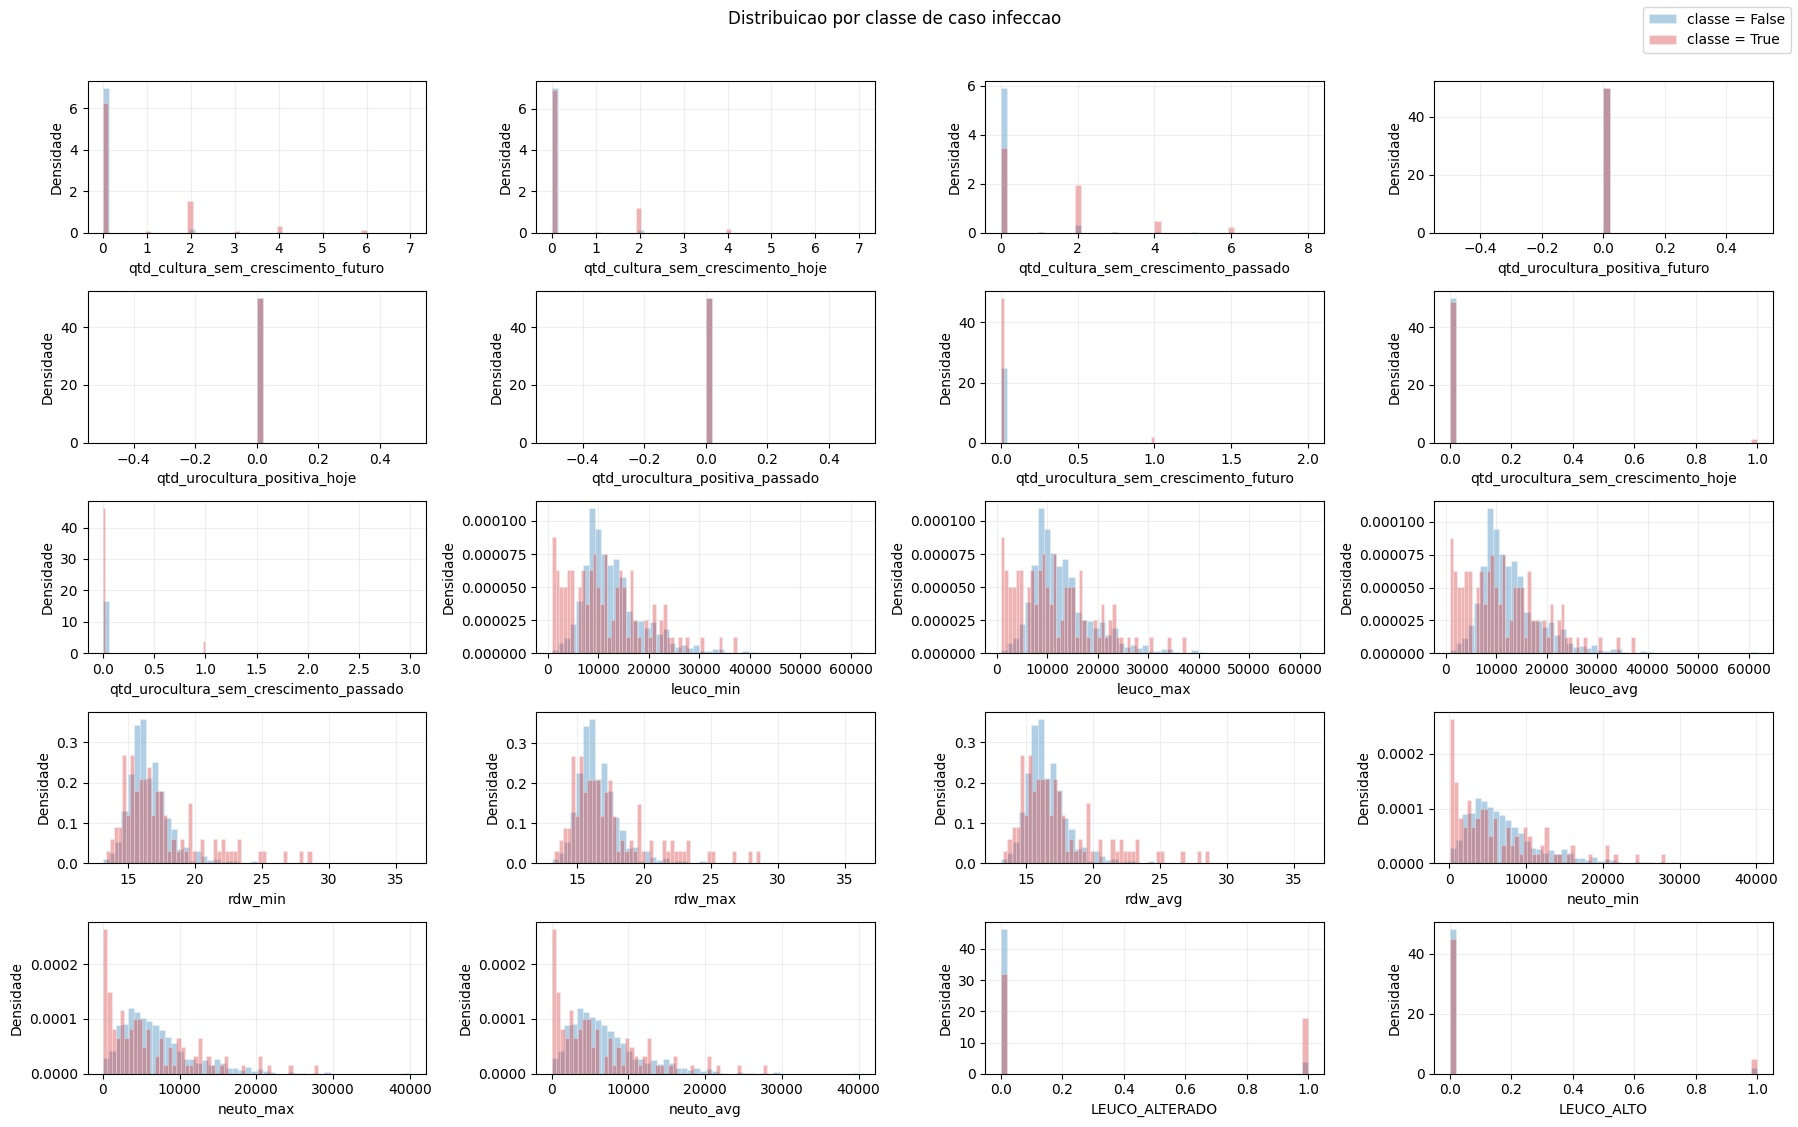

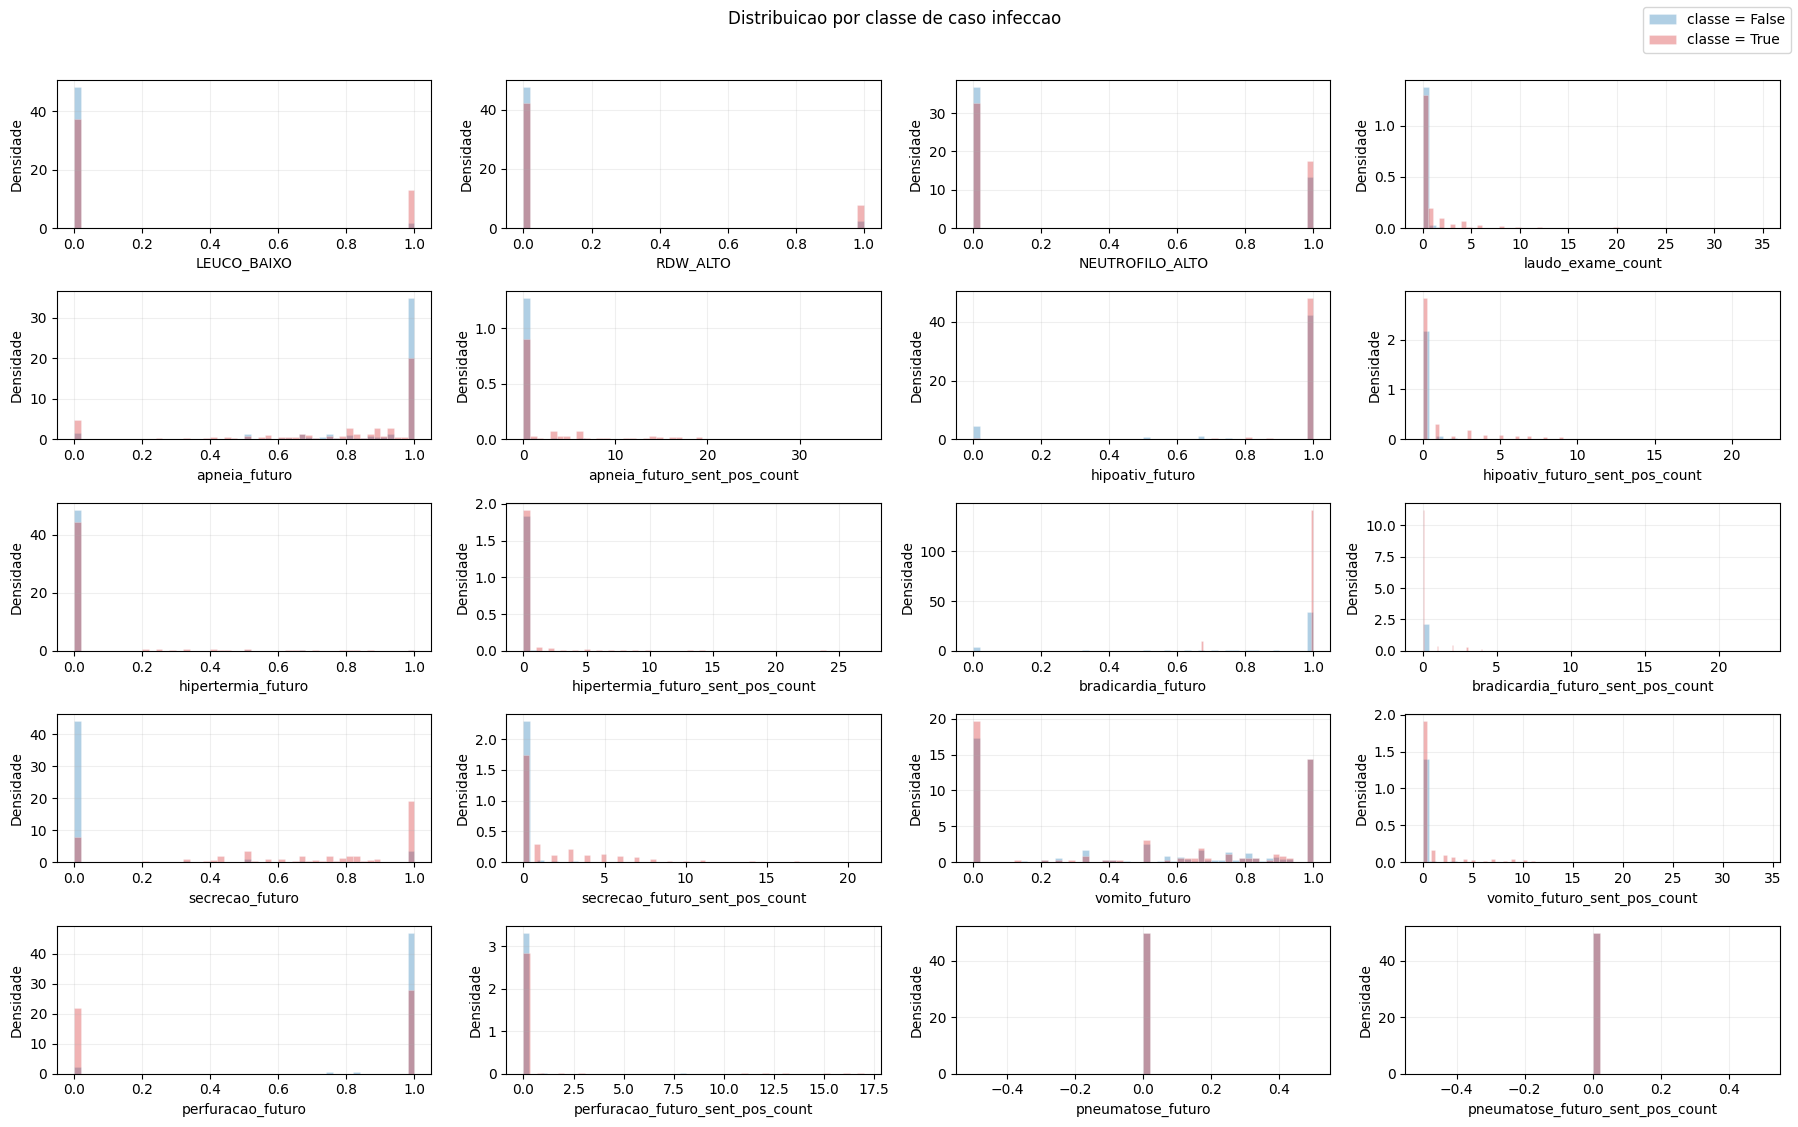

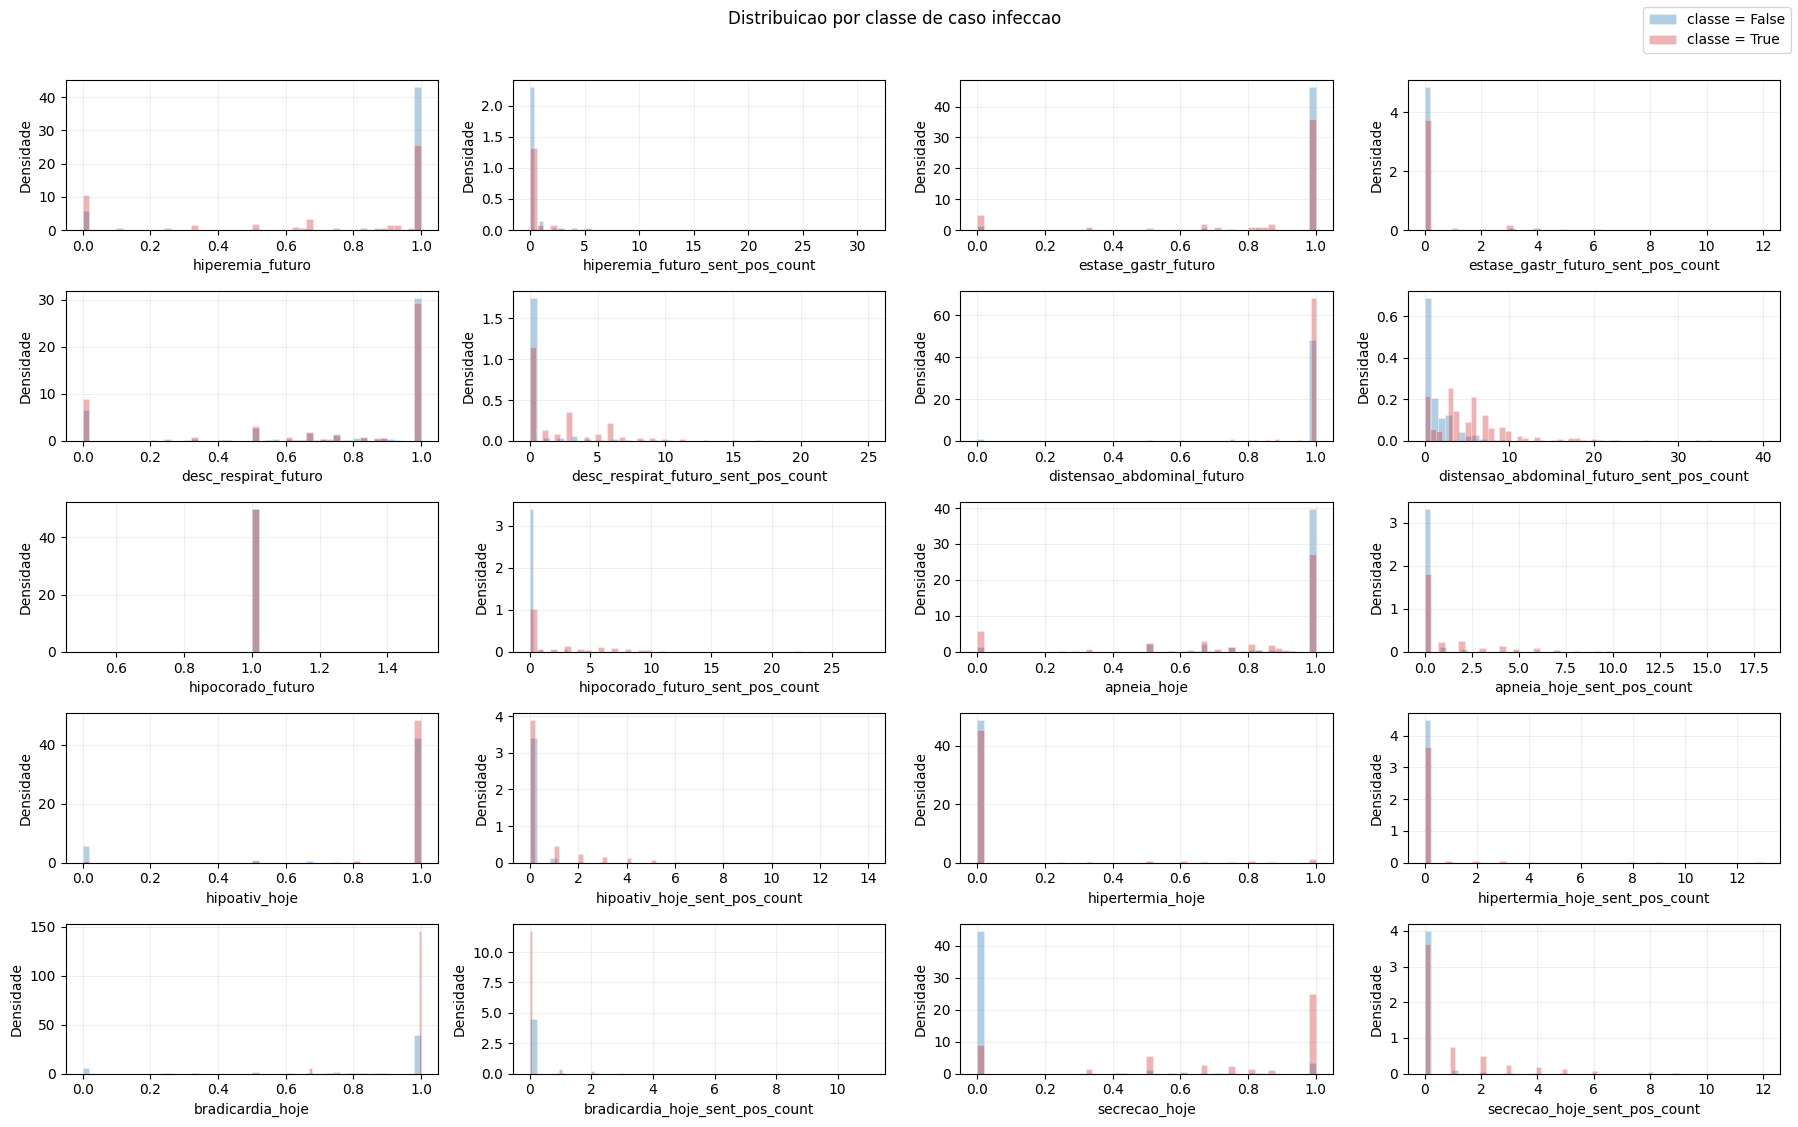

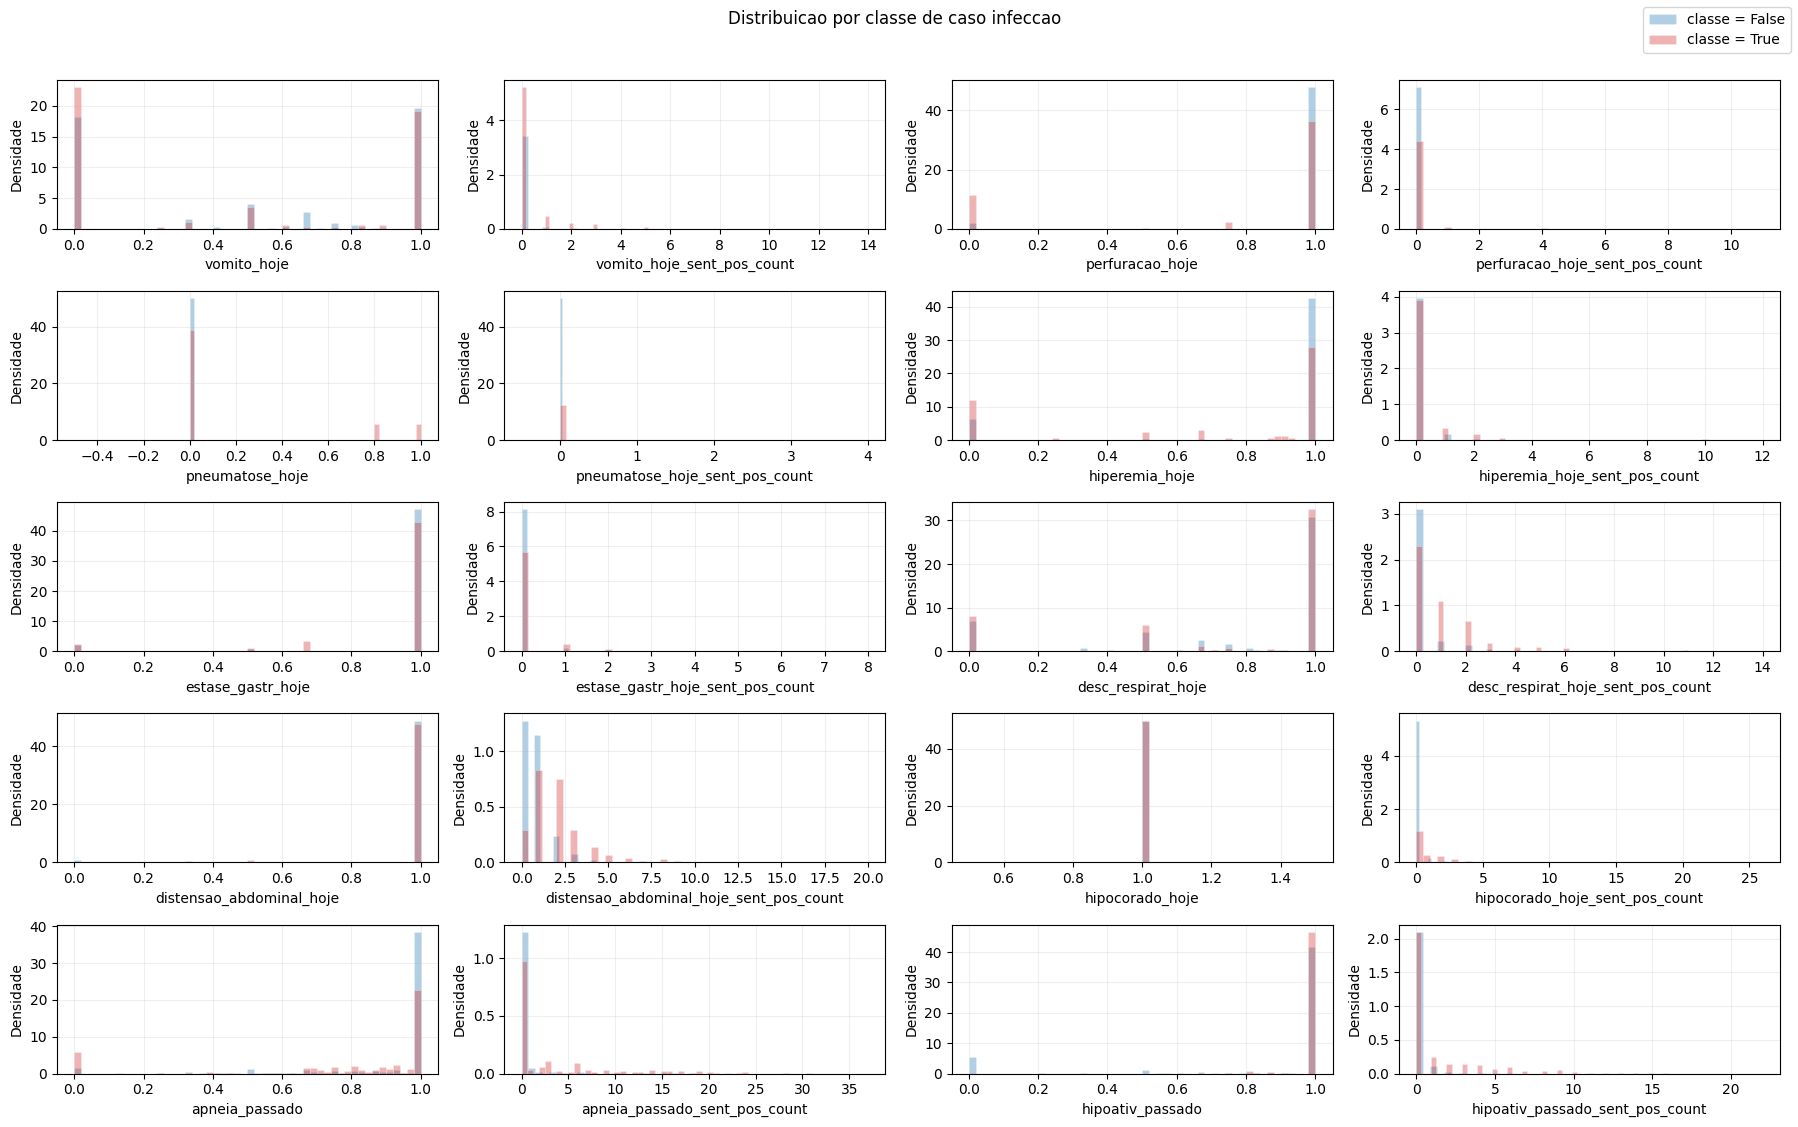

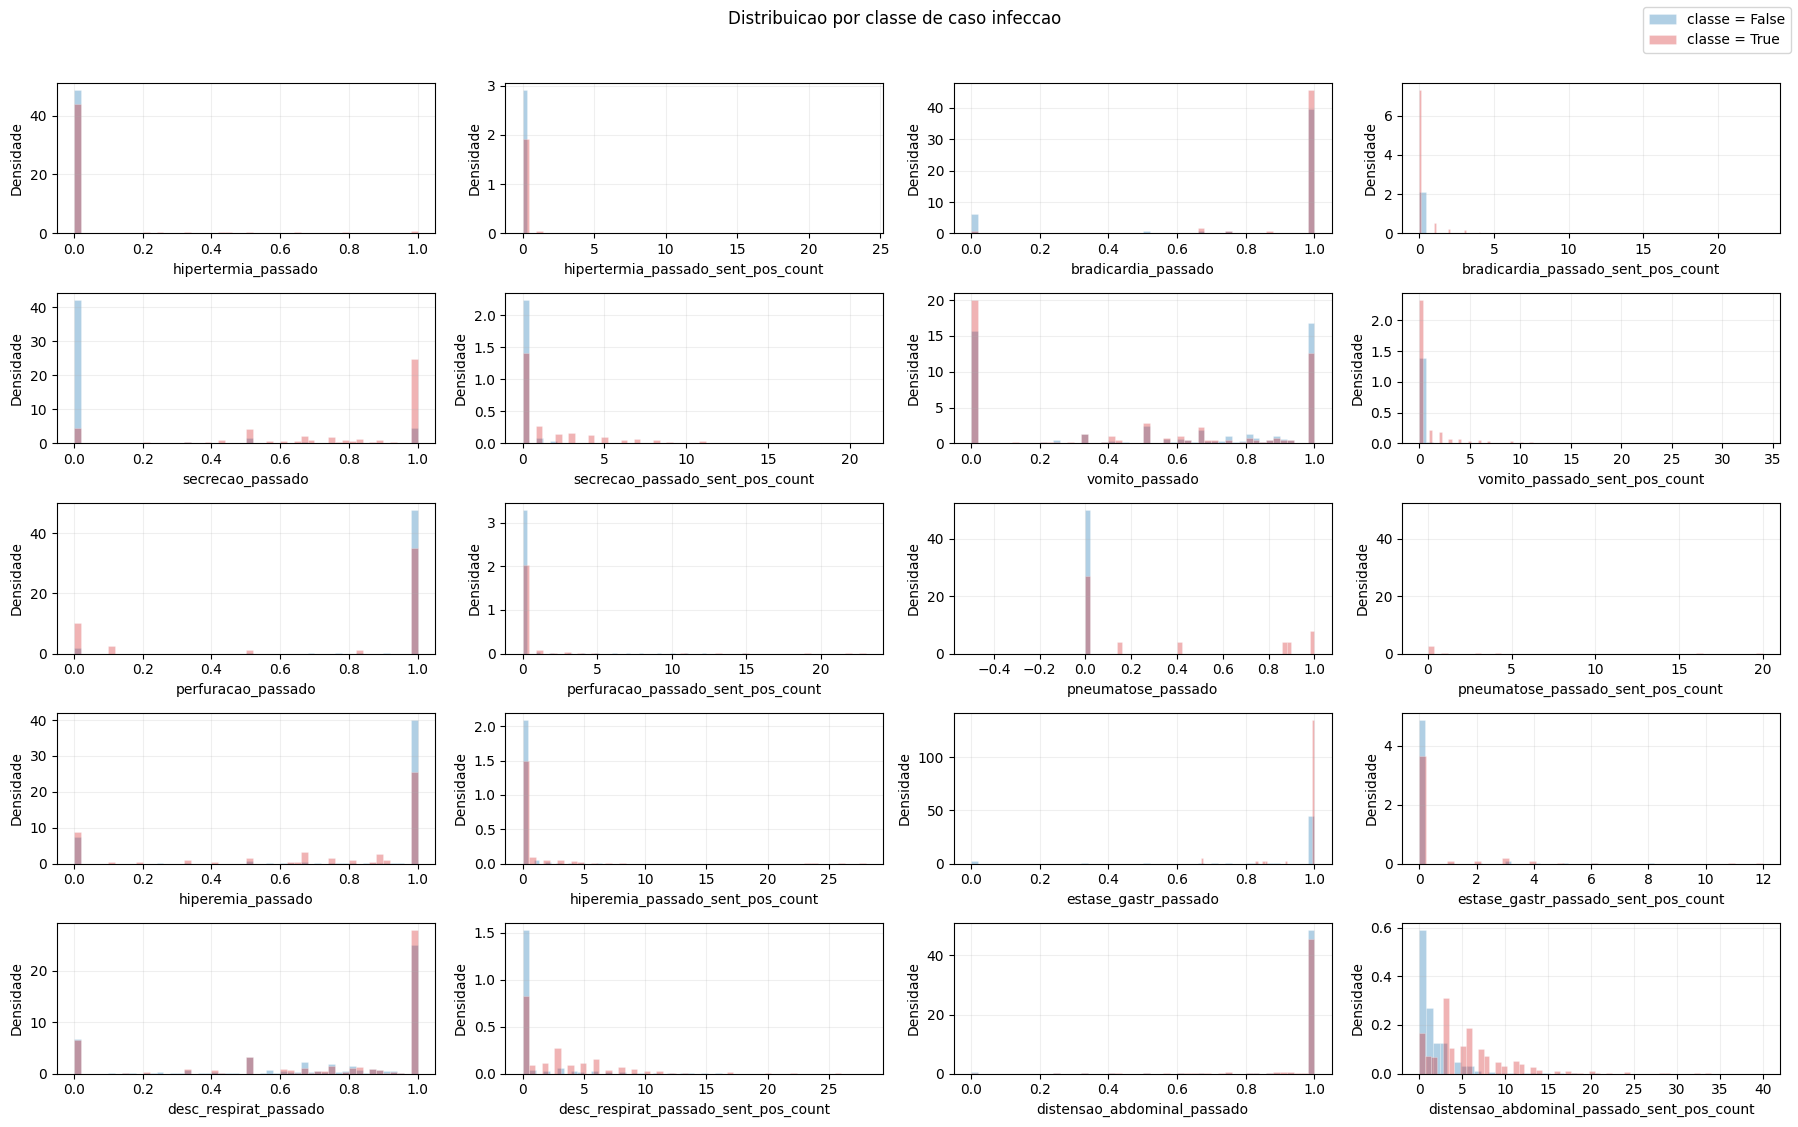

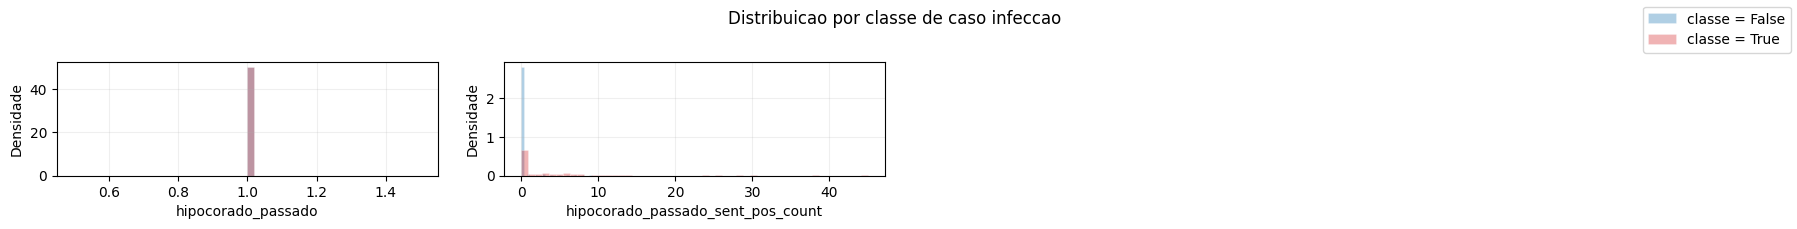

In [3]:
# from pathlib import Path

Y = df["caso infeccao"]
X = df.drop(columns=["caso infeccao", "registro", "dia_parsed"])

# opcional, mas recomendado: manter só numéricas para hist
X = X.select_dtypes(include=["number"])

chunk_size = 20
target_col = "caso infeccao"

# # Pasta de saída para salvar os gráficos
# output_dir = Path.home() / "Downloads" / "distribuicao_isa"
# output_dir.mkdir(parents=True, exist_ok=True)

for chunk_idx in range(math.ceil(len(X.columns) / chunk_size)):
    start = chunk_idx * chunk_size
    end = (chunk_idx + 1) * chunk_size
    current_features = X.columns[start:end]   # sem -1

    if len(current_features) == 0:
        continue

    plot_base = X[current_features].copy()
    plot_base[target_col] = Y.astype(str)
    classes = sorted(plot_base[target_col].dropna().unique())

    n_cols = 4
    n_rows = (len(current_features) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 2.2 * n_rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    colors = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"]

    for feat_idx, feature_name in enumerate(current_features):
        ax = axes[feat_idx]
        feature_df = plot_base[[feature_name, target_col]].dropna()

        for class_idx, classe in enumerate(classes):
            serie = feature_df.loc[feature_df[target_col] == classe, feature_name]
            ax.hist(
                serie,
                bins=50,
                alpha=0.35,
                density=True,
                label=f"classe = {classe}",
                color=colors[class_idx % len(colors)],
                edgecolor="white",
                linewidth=0.5,
            )

        ax.set_xlabel(feature_name)
        ax.set_ylabel("Densidade")
        ax.grid(alpha=0.2)

    for j in range(len(current_features), len(axes)):
        fig.delaxes(axes[j])

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    fig.suptitle("Distribuicao por classe de caso infeccao", y=1.02)
    plt.tight_layout()

    # # Salva cada figura (um arquivo por chunk de features)
    # file_name = f"distribuicao_caso_infeccao_chunk_{chunk_idx + 1:02d}.png"
    # file_path = output_dir / file_name
    # fig.savefig(file_path, dpi=200, bbox_inches="tight")
    # print(f"Grafico salvo em: {file_path}")

    plt.show()
    plt.close(fig)

# Dataset sem label

In [4]:
query = """
    select
        dtf.*
    from imparare2_dataset_label_full dtf
"""

df_no_label = dataRequest.get_data(queryText= query, chunck= None)

In [5]:
criterios = [f"{cri}{t}"for cri in maestro.CRITERIOS_FEATURE_EXTRACTION_MODELO for t in maestro.CRITERIOS_TEMPORAL_SUFFIX]

Grafico salvo em: /home/linux-5900xt/Downloads/distribuicao_isa_sem_classe/distribuicao_sem_classe_chunk_01.png


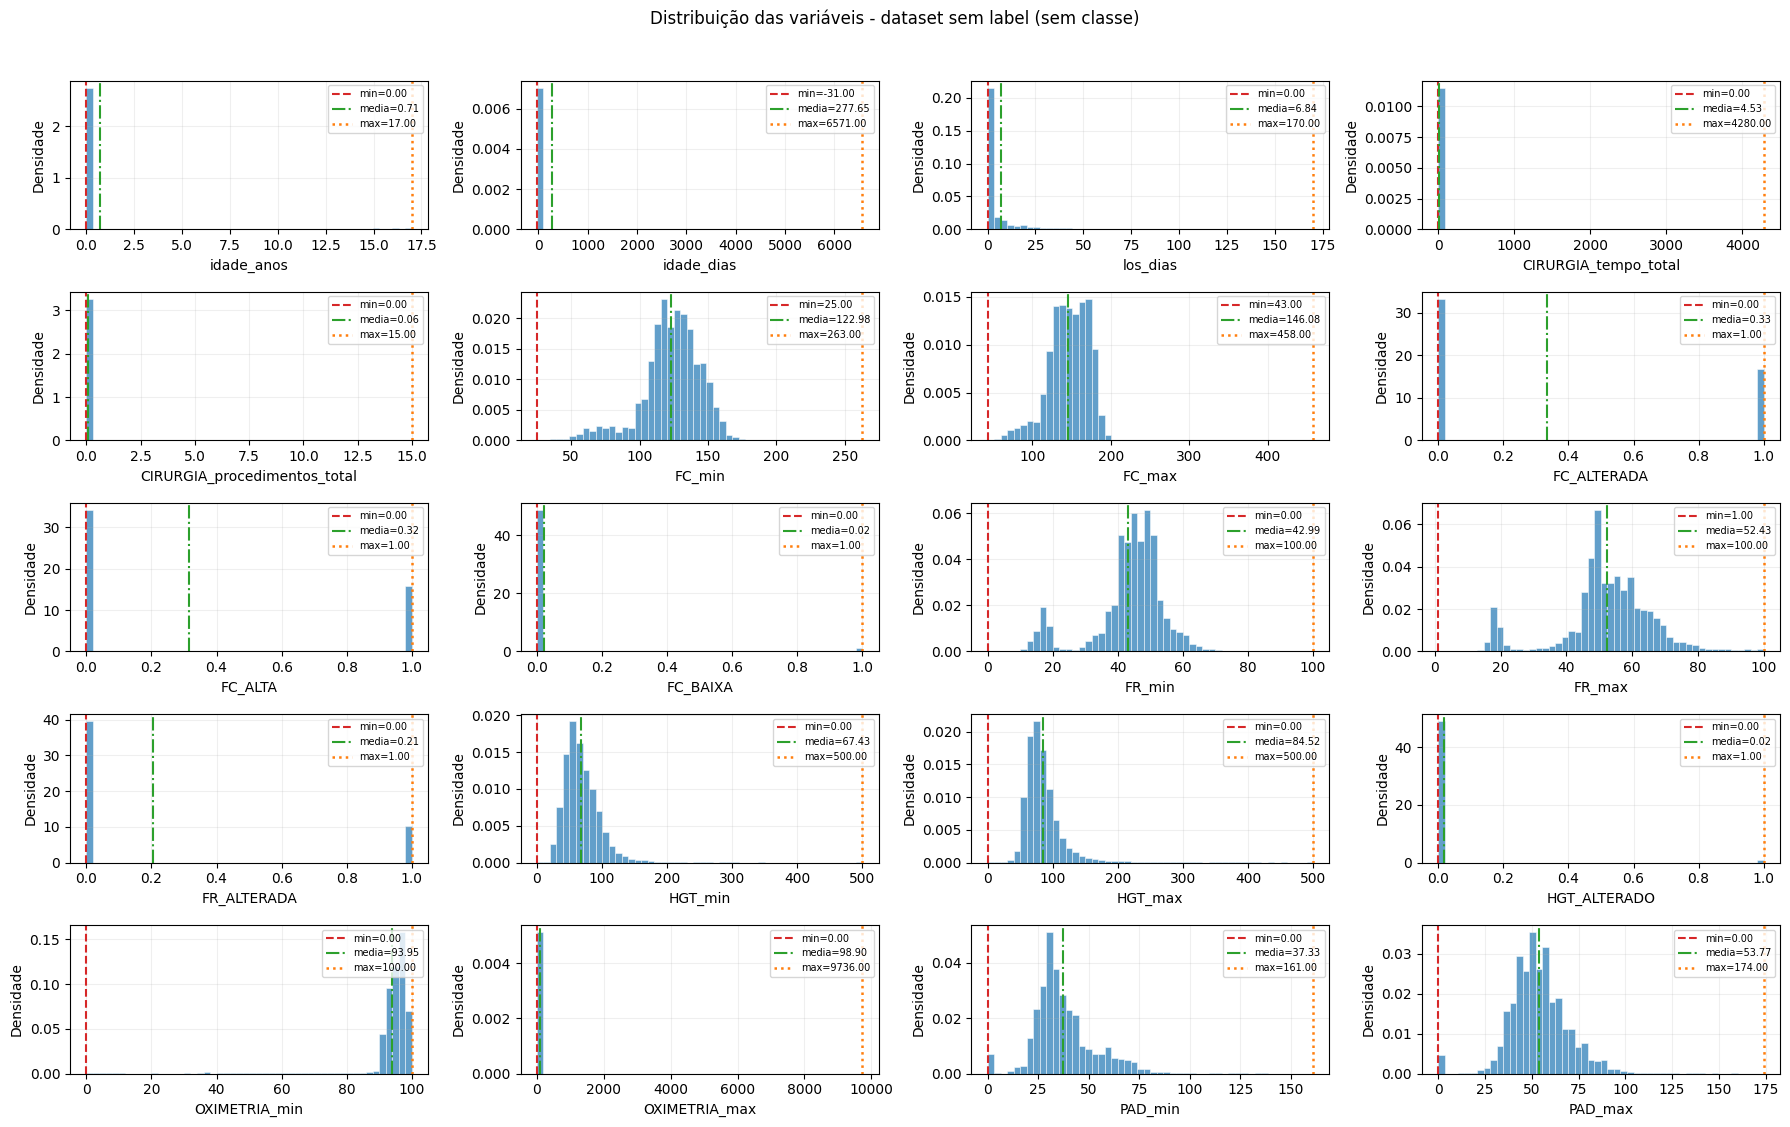

Grafico salvo em: /home/linux-5900xt/Downloads/distribuicao_isa_sem_classe/distribuicao_sem_classe_chunk_02.png


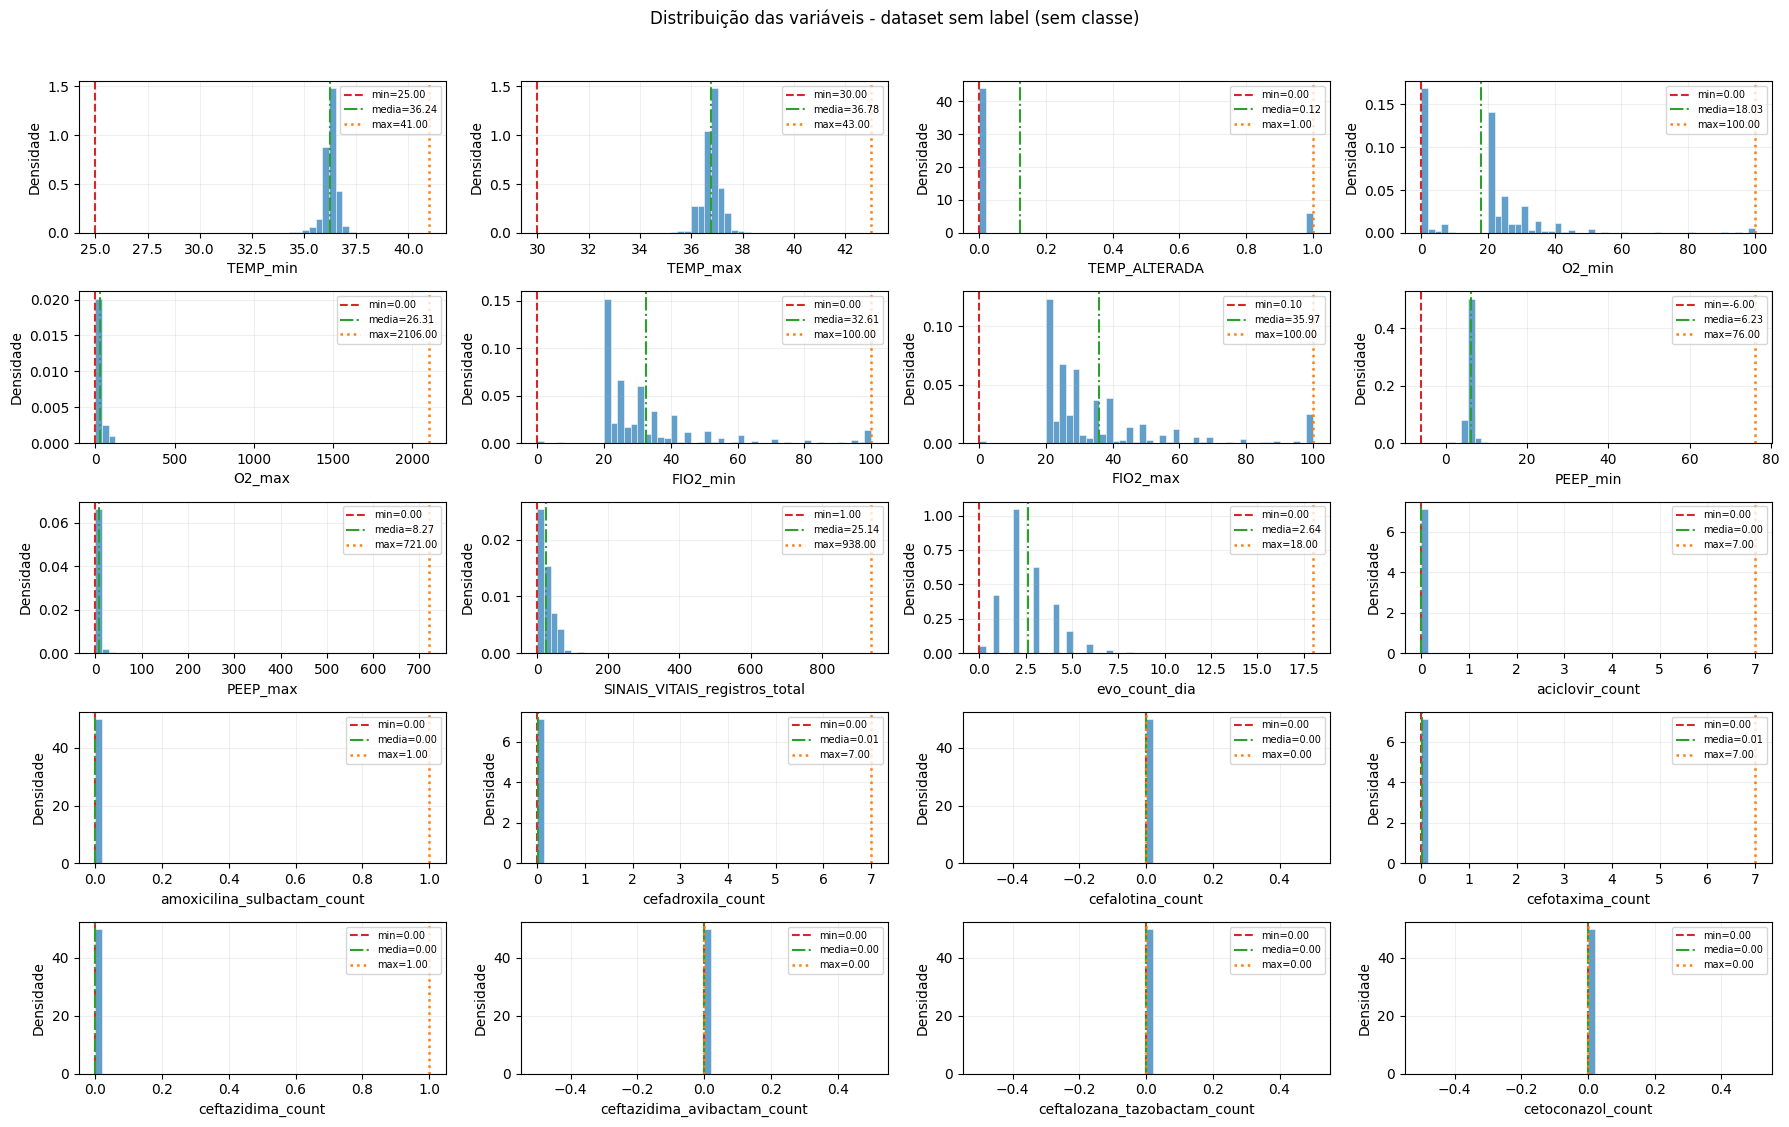

Grafico salvo em: /home/linux-5900xt/Downloads/distribuicao_isa_sem_classe/distribuicao_sem_classe_chunk_03.png


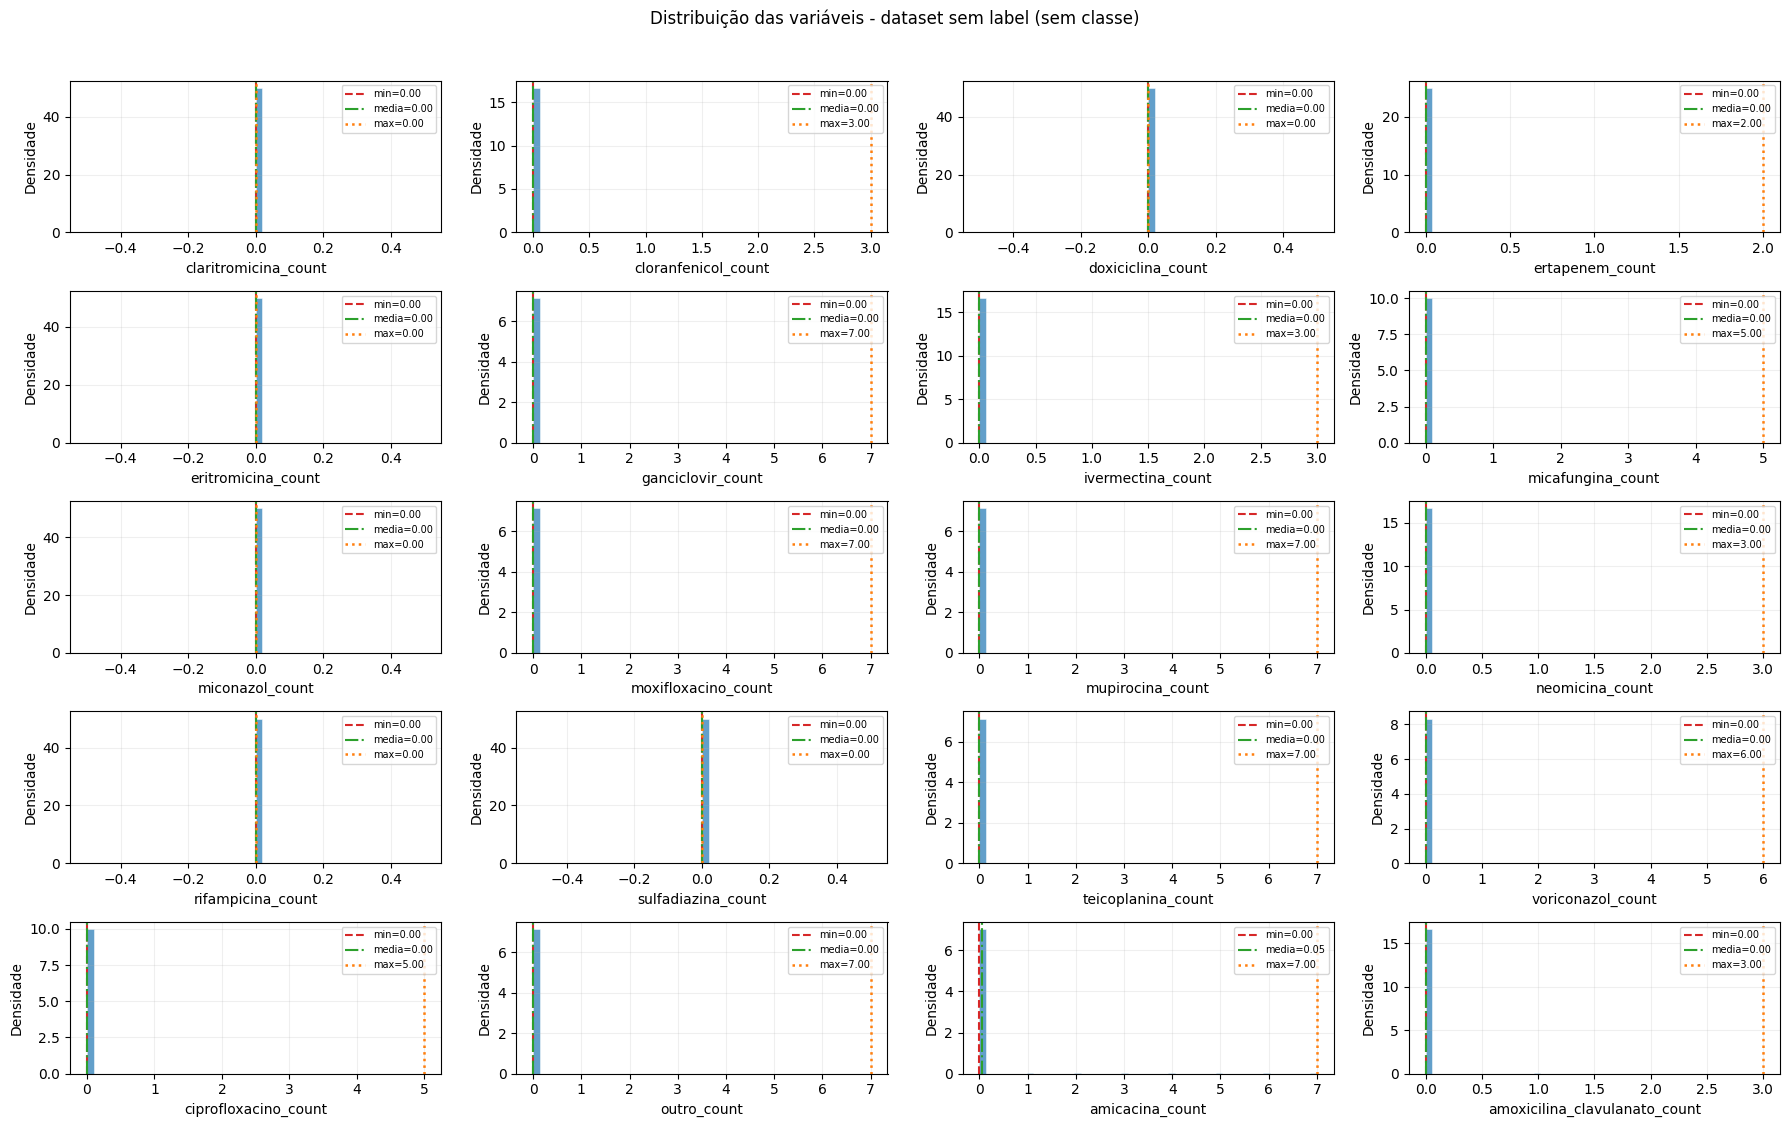

Grafico salvo em: /home/linux-5900xt/Downloads/distribuicao_isa_sem_classe/distribuicao_sem_classe_chunk_04.png


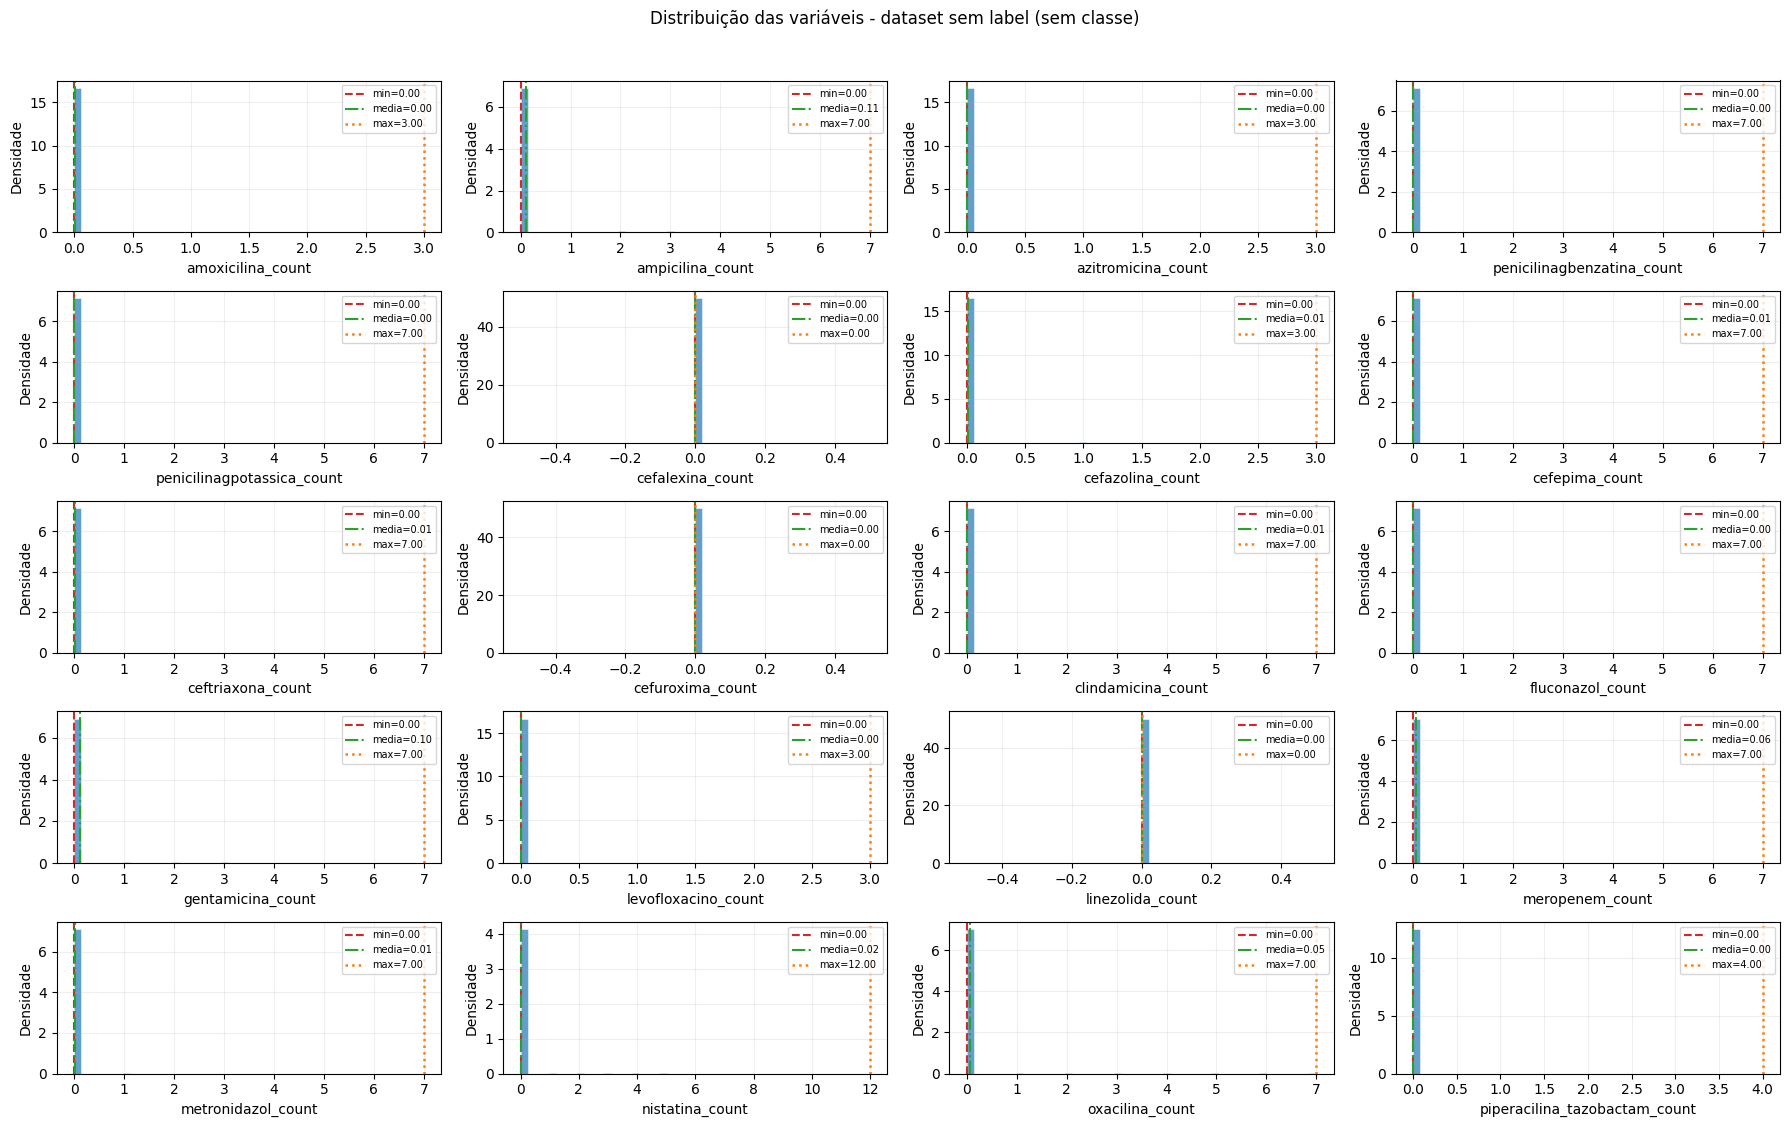

Grafico salvo em: /home/linux-5900xt/Downloads/distribuicao_isa_sem_classe/distribuicao_sem_classe_chunk_05.png


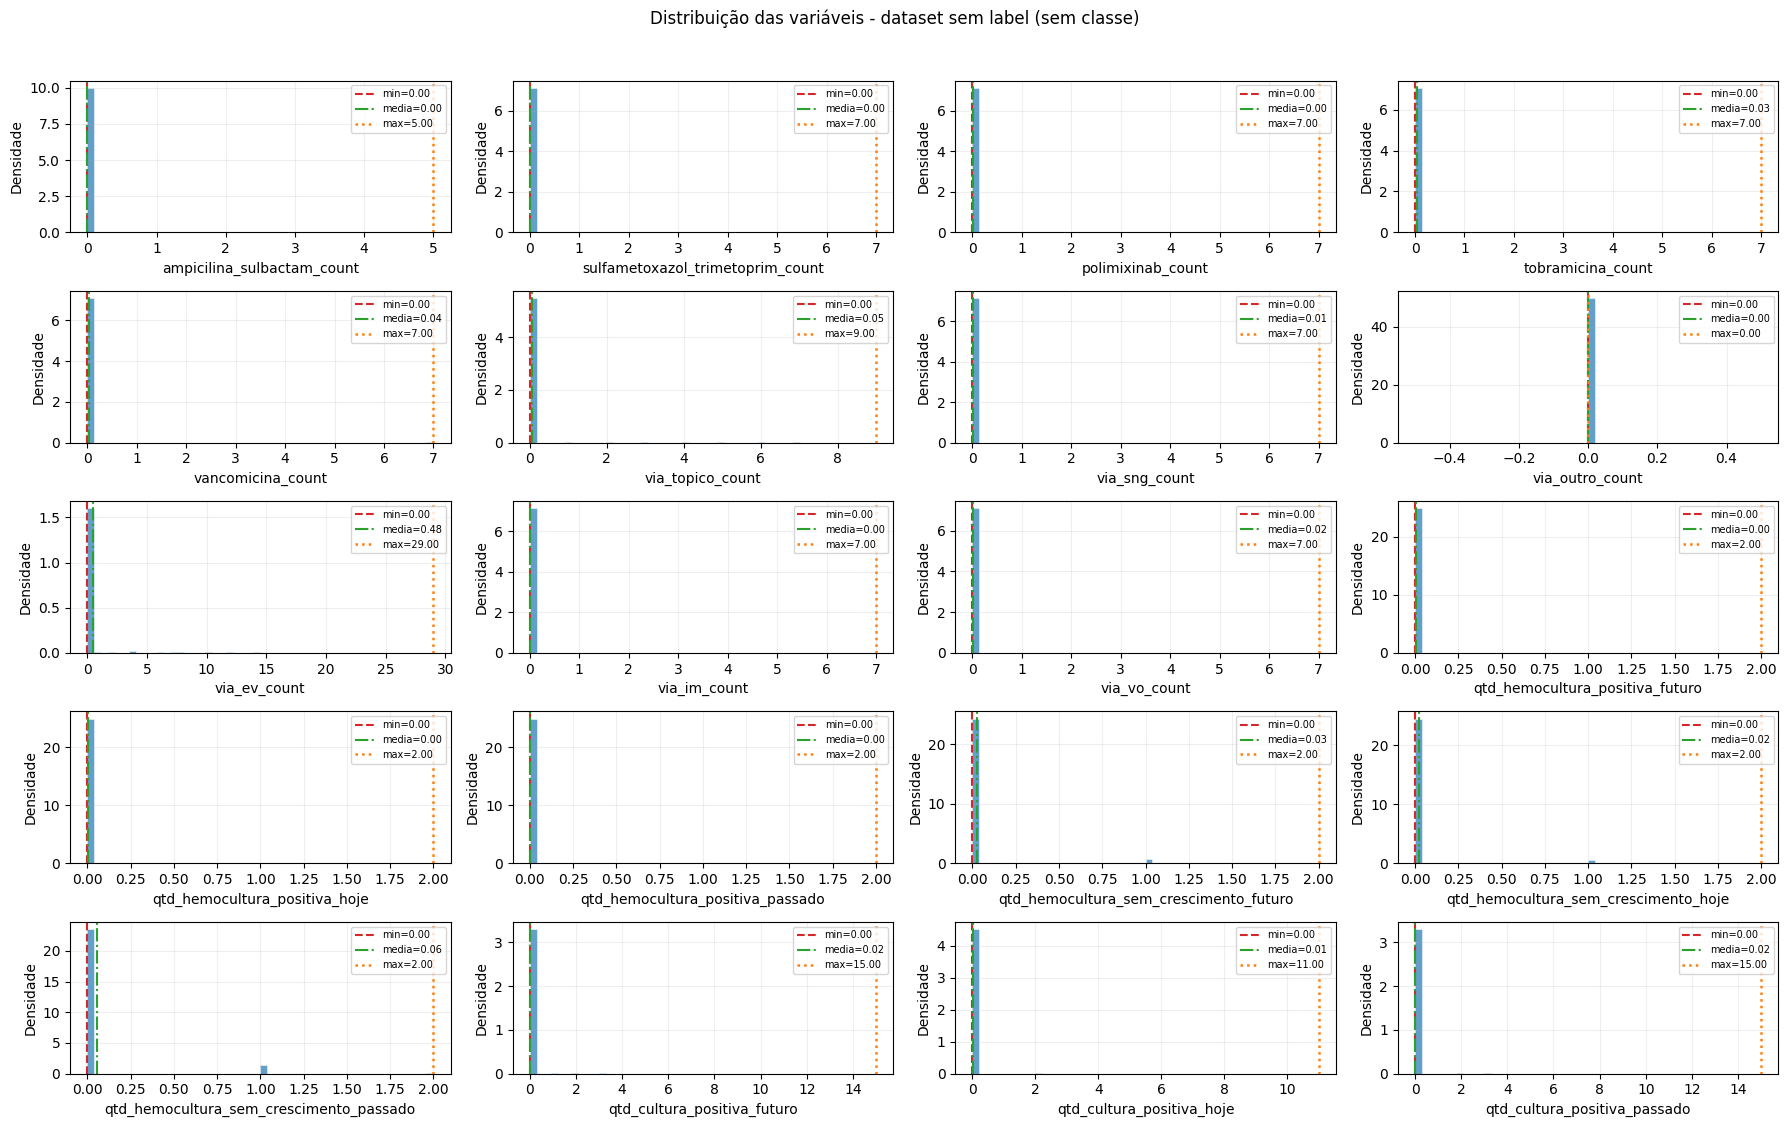

Grafico salvo em: /home/linux-5900xt/Downloads/distribuicao_isa_sem_classe/distribuicao_sem_classe_chunk_06.png


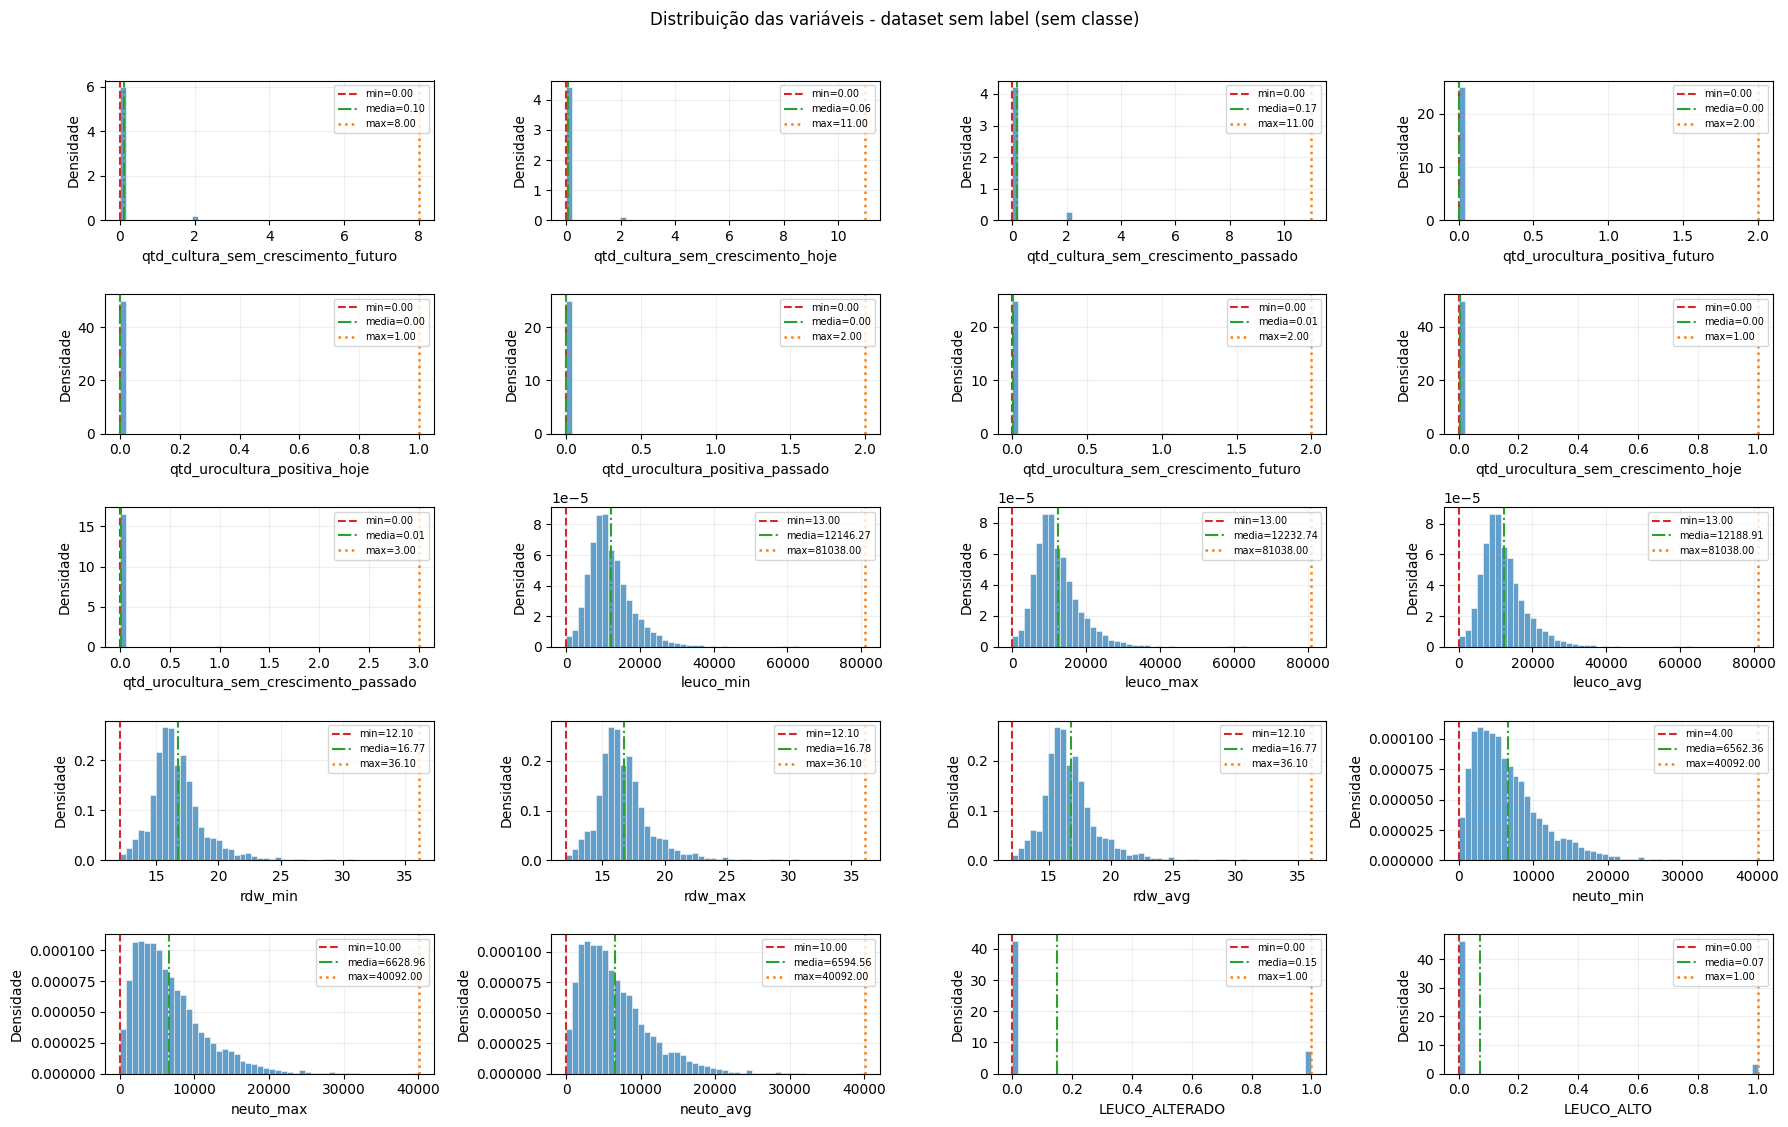

Grafico salvo em: /home/linux-5900xt/Downloads/distribuicao_isa_sem_classe/distribuicao_sem_classe_chunk_07.png


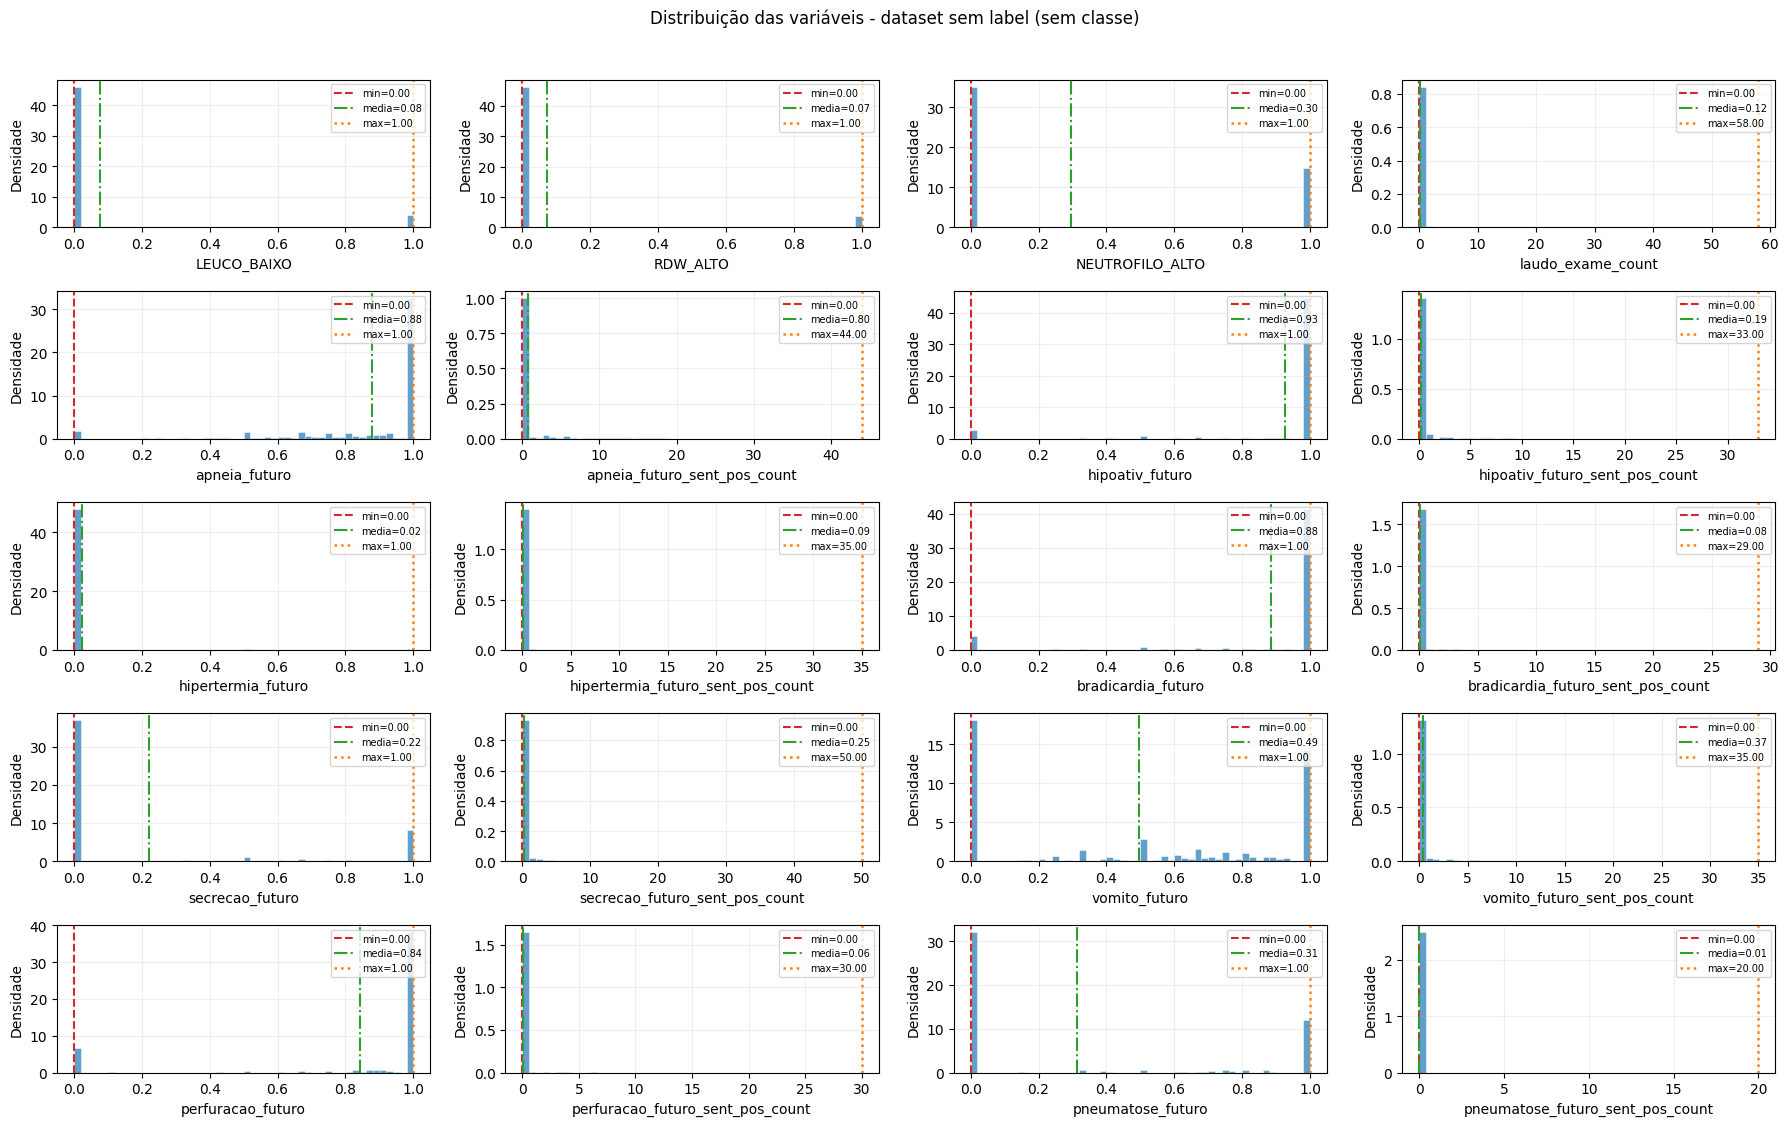

Grafico salvo em: /home/linux-5900xt/Downloads/distribuicao_isa_sem_classe/distribuicao_sem_classe_chunk_08.png


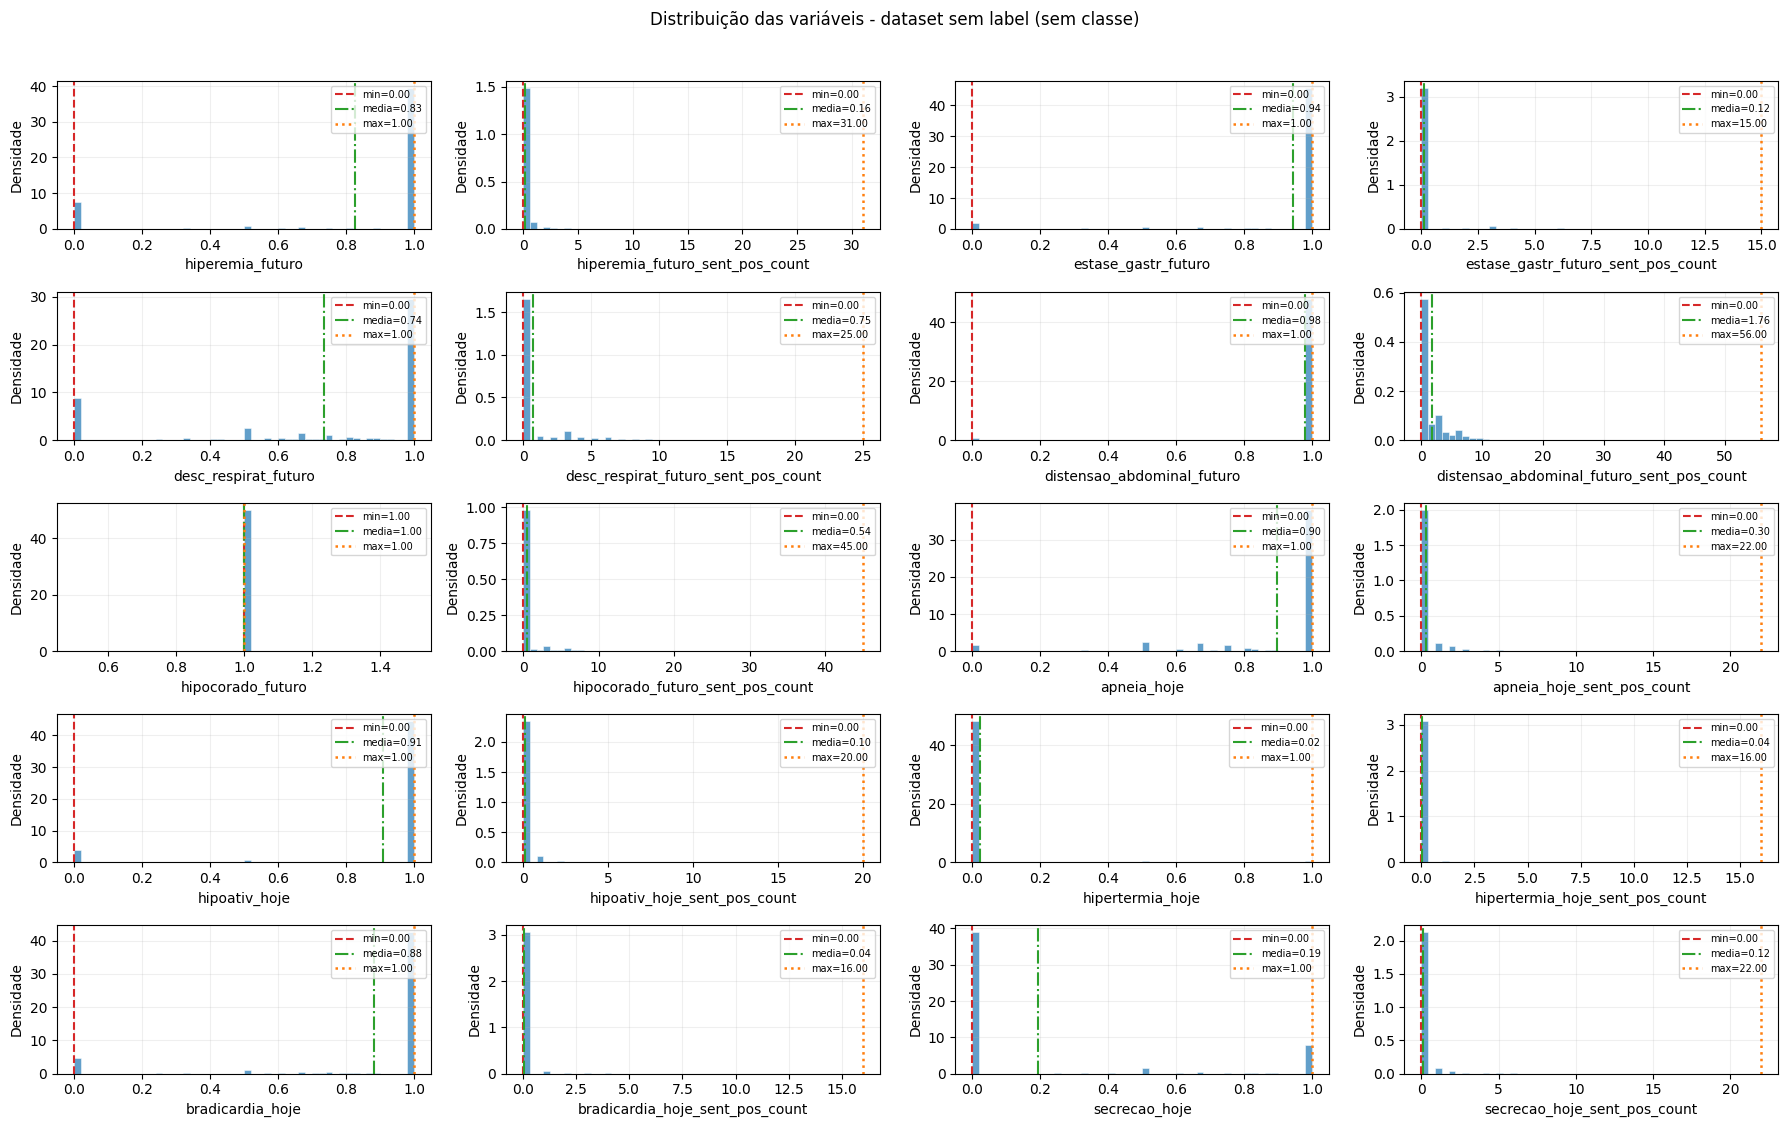

Grafico salvo em: /home/linux-5900xt/Downloads/distribuicao_isa_sem_classe/distribuicao_sem_classe_chunk_09.png


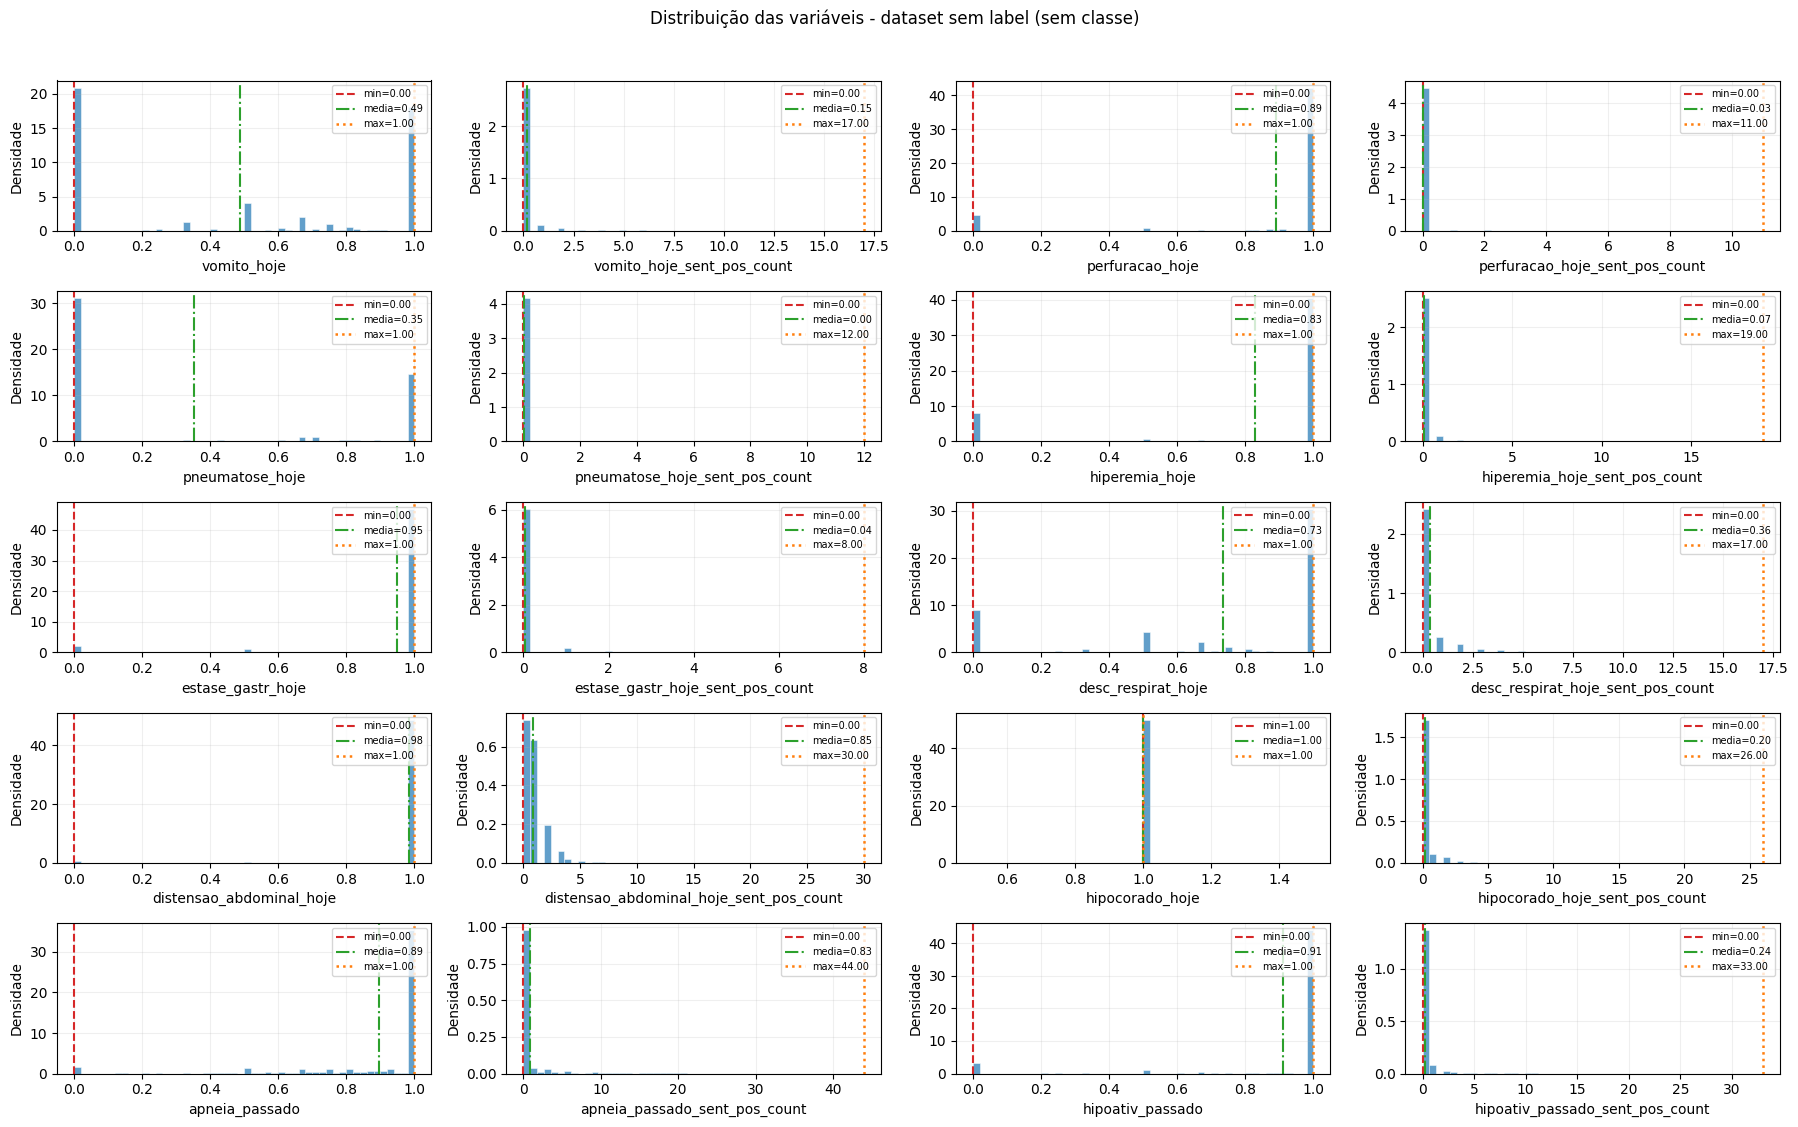

Grafico salvo em: /home/linux-5900xt/Downloads/distribuicao_isa_sem_classe/distribuicao_sem_classe_chunk_10.png


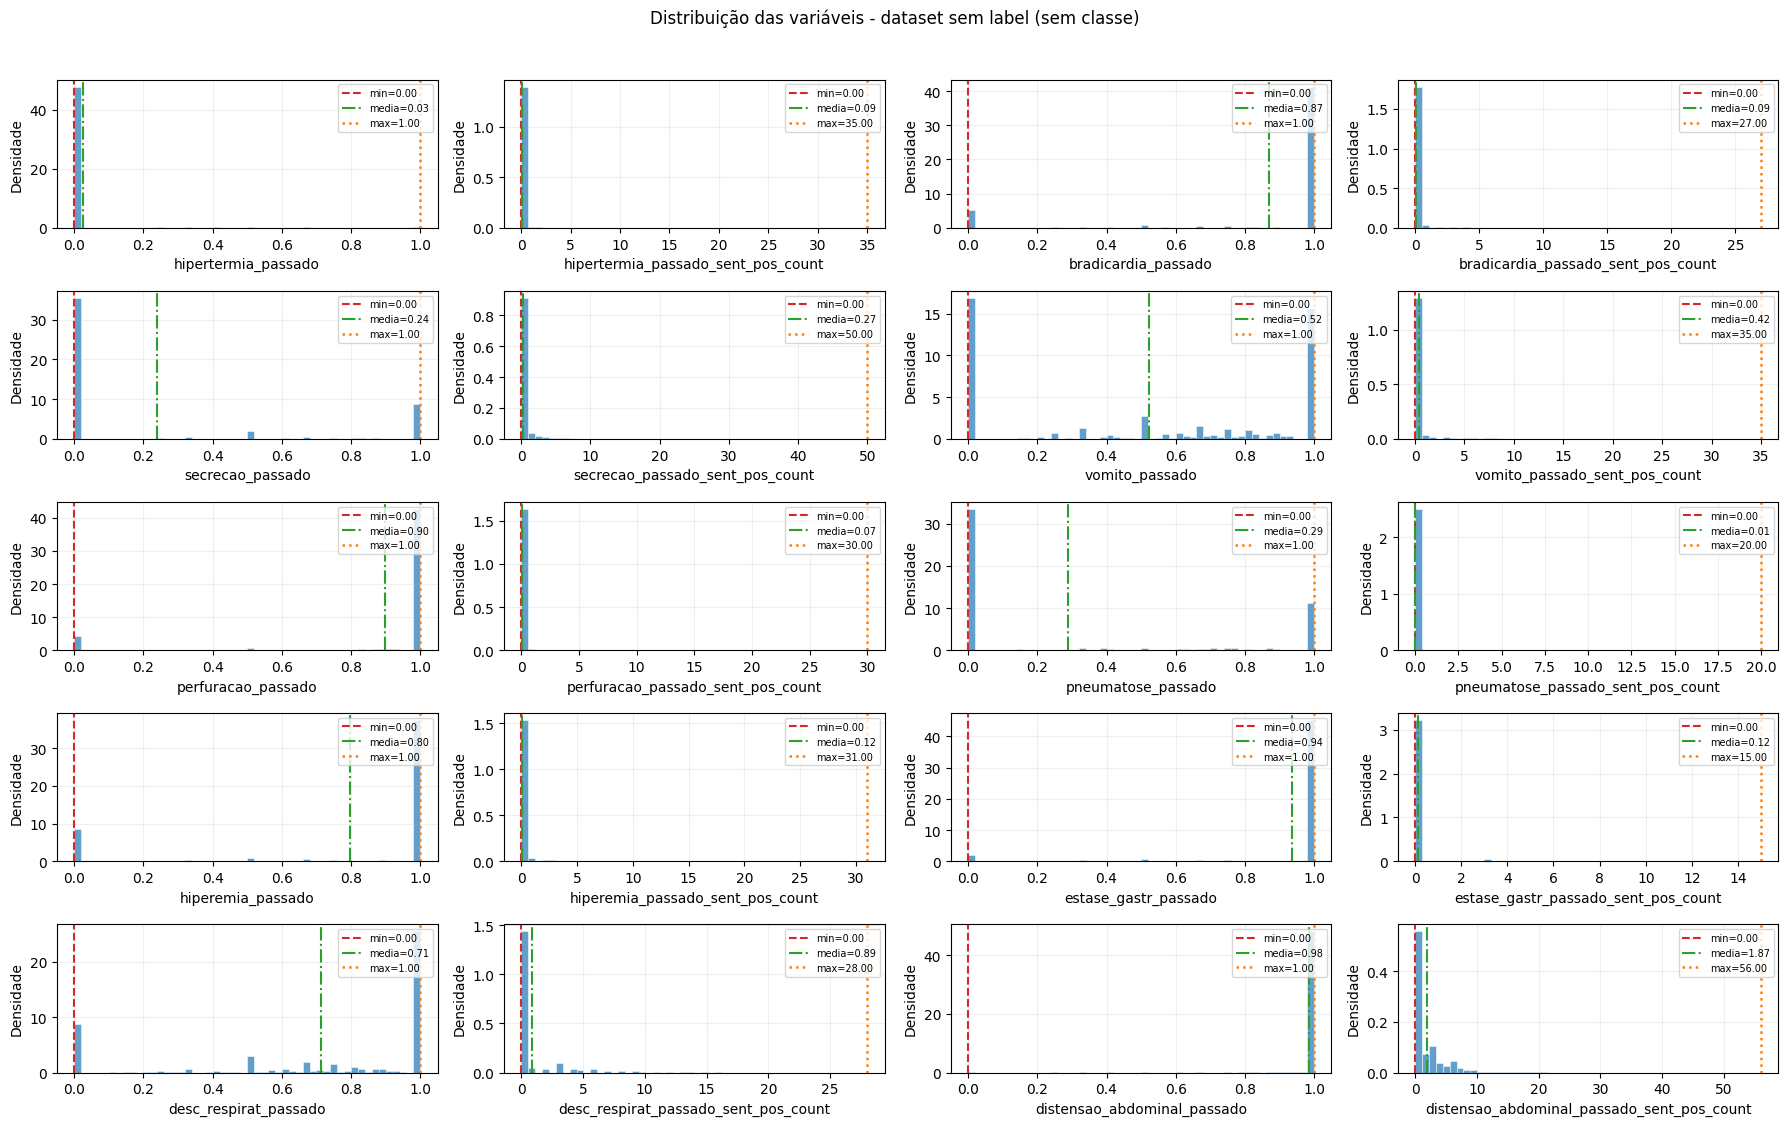

Grafico salvo em: /home/linux-5900xt/Downloads/distribuicao_isa_sem_classe/distribuicao_sem_classe_chunk_11.png


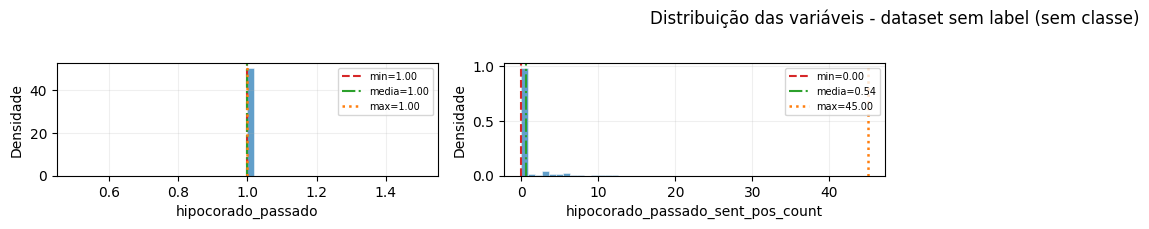

In [6]:
from pathlib import Path

X = df_no_label.drop(columns=["caso infeccao", "registro", "dia_parsed"], errors="ignore")

# opcional, mas recomendado: manter só numéricas para hist
X = X.select_dtypes(include=["number"])

chunk_size = 20

# Pasta de saída para salvar os gráficos
output_dir = Path.home() / "Downloads" / "distribuicao_isa_sem_classe"
output_dir.mkdir(parents=True, exist_ok=True)

for chunk_idx in range(math.ceil(len(X.columns) / chunk_size)):
    start = chunk_idx * chunk_size
    end = (chunk_idx + 1) * chunk_size
    current_features = X.columns[start:end]

    if len(current_features) == 0:
        continue

    plot_base = X[current_features].copy()

    n_cols = 4
    n_rows = (len(current_features) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 2.2 * n_rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for feat_idx, feature_name in enumerate(current_features):
        ax = axes[feat_idx]
        serie = plot_base[feature_name].dropna()

        if serie.empty:
            ax.text(0.5, 0.5, "Sem dados", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(feature_name)
            ax.grid(alpha=0.2)
            continue

        ax.hist(
            serie,
            bins=50,
            alpha=0.7,
            density=True,
            color="#1f77b4",
            edgecolor="white",
            linewidth=0.5,
        )

        vmin = serie.min()
        vmean = serie.mean()
        vmax = serie.max()

        ax.axvline(vmin, color="#d62728", linestyle="--", linewidth=1.5, label=f"min={vmin:.2f}")
        ax.axvline(vmean, color="#2ca02c", linestyle="-.", linewidth=1.5, label=f"media={vmean:.2f}")
        ax.axvline(vmax, color="#ff7f0e", linestyle=":", linewidth=1.8, label=f"max={vmax:.2f}")

        ax.set_xlabel(feature_name)
        ax.set_ylabel("Densidade")
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, loc="upper right")

    for j in range(len(current_features), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Distribuição das variáveis - dataset sem label (sem classe)", y=1.02)
    plt.tight_layout()

    # Salva cada figura (um arquivo por chunk de features)
    file_name = f"distribuicao_sem_classe_chunk_{chunk_idx + 1:02d}.png"
    file_path = output_dir / file_name
    fig.savefig(file_path, dpi=200, bbox_inches="tight")
    print(f"Grafico salvo em: {file_path}")

    plt.show()
    plt.close(fig)

# Codigo gpt, exploração


===== Painel de critérios | Dataset com label =====
Total de critérios gerados: 39
Presentes no dataset: 39
Ausentes no dataset: 0
Numéricos variáveis (usáveis): 39
Constantes: 0

Critérios mais raros (maior % de zero):


,criterio,pct_zero,pct_nonzero
0,pneumatose_futuro,1.000000,0.000000
1,pneumatose_hoje,0.999932,0.000068
2,pneumatose_passado,0.999797,0.000203
3,perfuracao_futuro,0.995667,0.004333
4,perfuracao_hoje,0.993365,0.006635
5,hipertermia_hoje,0.989743,0.010257
6,hipertermia_passado,0.988389,0.011611
7,hipertermia_futuro,0.986933,0.013067
8,bradicardia_futuro,0.985511,0.014489
9,perfuracao_passado,0.985443,0.014557



Critérios mais frequentes (maior % não-zero):


,criterio,pct_zero,pct_nonzero
38,distensao_abdominal_hoje,0.453791,0.546209
37,distensao_abdominal_passado,0.465978,0.534022
36,distensao_abdominal_futuro,0.542823,0.457177
35,desc_respirat_passado,0.849188,0.150812
34,desc_respirat_hoje,0.862153,0.137847
33,desc_respirat_futuro,0.869160,0.130840
32,apneia_passado,0.904807,0.095193
31,hiperemia_futuro,0.916622,0.083378
30,hipoativ_passado,0.918450,0.081550
29,apneia_hoje,0.926608,0.073392


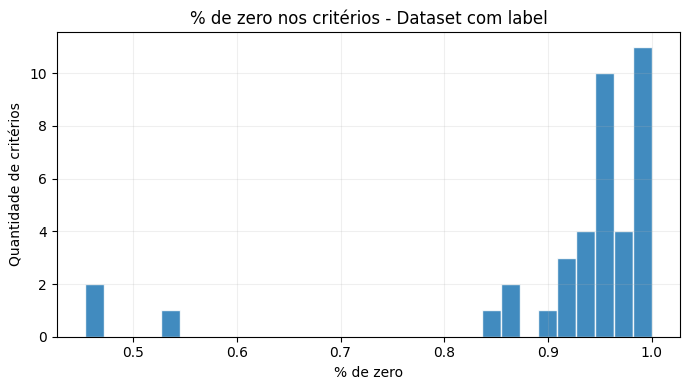


===== Painel de critérios | Dataset sem label =====
Total de critérios gerados: 39
Presentes no dataset: 39
Ausentes no dataset: 0
Numéricos variáveis (usáveis): 39
Constantes: 0

Critérios mais raros (maior % de zero):


,criterio,pct_zero,pct_nonzero
0,pneumatose_hoje,0.999217,0.000783
1,pneumatose_passado,0.998925,0.001075
2,pneumatose_futuro,0.998872,0.001128
3,perfuracao_futuro,0.991052,0.008948
4,perfuracao_hoje,0.988410,0.011590
5,hipertermia_hoje,0.983007,0.016993
6,perfuracao_passado,0.981586,0.018414
7,hipertermia_passado,0.980404,0.019596
8,hipertermia_futuro,0.980112,0.019888
9,bradicardia_hoje,0.977046,0.022954



Critérios mais frequentes (maior % não-zero):


,criterio,pct_zero,pct_nonzero
38,distensao_abdominal_hoje,0.443371,0.556629
37,distensao_abdominal_passado,0.459700,0.540300
36,distensao_abdominal_futuro,0.510455,0.489545
35,desc_respirat_passado,0.805544,0.194456
34,desc_respirat_hoje,0.822591,0.177409
33,desc_respirat_futuro,0.827848,0.172152
32,apneia_passado,0.858357,0.141643
31,apneia_hoje,0.876691,0.123309
30,hipocorado_futuro,0.881165,0.118835
29,hipocorado_passado,0.882652,0.117348


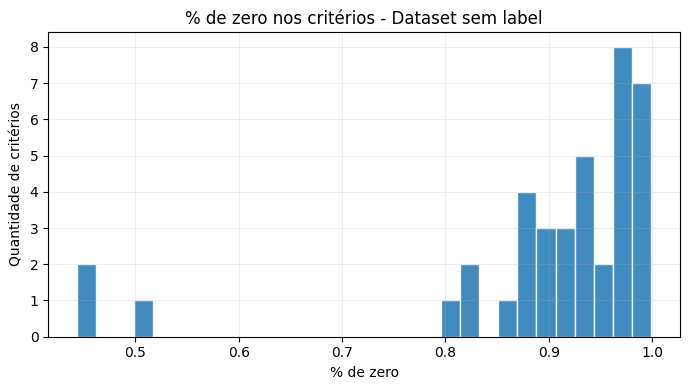

In [7]:
def painel_criterios(dataframe, criterios_lista, nome_base, top_n=20):
    cols_presentes = [c for c in criterios_lista if c in dataframe.columns]
    cols_ausentes = [c for c in criterios_lista if c not in dataframe.columns]

    base = dataframe[cols_presentes].select_dtypes(include=[np.number]).copy()
    nunique = base.nunique(dropna=False)
    cols_constantes = nunique[nunique <= 1].index.tolist()
    cols_variaveis = nunique[nunique > 1].index.tolist()

    base_var = base[cols_variaveis].copy()
    pct_zero = (base_var.fillna(0) == 0).mean().sort_values(ascending=False) if len(cols_variaveis) else pd.Series(dtype=float)
    pct_nonzero = 1 - pct_zero if len(cols_variaveis) else pd.Series(dtype=float)

    print(f"\n===== Painel de critérios | {nome_base} =====")
    print(f"Total de critérios gerados: {len(criterios_lista)}")
    print(f"Presentes no dataset: {len(cols_presentes)}")
    print(f"Ausentes no dataset: {len(cols_ausentes)}")
    print(f"Numéricos variáveis (usáveis): {len(cols_variaveis)}")
    print(f"Constantes: {len(cols_constantes)}")

    if len(cols_ausentes) > 0:
        print("\nExemplo de critérios ausentes (até 20):")
        print(cols_ausentes[:20])

    if len(cols_constantes) > 0:
        print("\nExemplo de critérios constantes (até 20):")
        print(cols_constantes[:20])

    if len(cols_variaveis) > 0:
        resumo = pd.DataFrame({
            "criterio": pct_zero.index,
            "pct_zero": pct_zero.values,
            "pct_nonzero": pct_nonzero.values,
        })
        print("\nCritérios mais raros (maior % de zero):")
        display(resumo.head(top_n))
        print("\nCritérios mais frequentes (maior % não-zero):")
        display(resumo.sort_values("pct_nonzero", ascending=False).head(top_n))

        plt.figure(figsize=(7, 4))
        plt.hist(pct_zero.values, bins=30, alpha=0.85, edgecolor="white")
        plt.title(f"% de zero nos critérios - {nome_base}")
        plt.xlabel("% de zero")
        plt.ylabel("Quantidade de critérios")
        plt.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()
    else:
        print("Sem critérios variáveis para resumir.")

    return {
        "presentes": cols_presentes,
        "ausentes": cols_ausentes,
        "constantes": cols_constantes,
        "variaveis": cols_variaveis,
        "pct_zero": pct_zero,
    }

painel_com_label = painel_criterios(df, criterios, "Dataset com label", top_n=15)
painel_sem_label = painel_criterios(df_no_label, criterios, "Dataset sem label", top_n=15)

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def preparar_base_criterios(dataframe, criterios_lista):
    cols_existentes = [c for c in criterios_lista if c in dataframe.columns]
    base = dataframe[cols_existentes].select_dtypes(include=[np.number]).copy()
    base = base.replace([np.inf, -np.inf], np.nan)
    base = base.dropna(axis=1, how="all")

    # Remove features constantes para evitar warnings e distorcoes nas metricas.
    variacao = base.nunique(dropna=False)
    cols_nao_constantes = variacao[variacao > 1].index
    base = base[cols_nao_constantes]

    return base

def executar_pca(base_numerica, nome_base, variancia_alvo=0.95):
    if base_numerica.empty:
        print(f"[{nome_base}] Sem colunas numéricas válidas para PCA.")
        return None

    base_limpa = base_numerica.dropna()
    if base_limpa.shape[0] < 3 or base_limpa.shape[1] < 2:
        print(f"[{nome_base}] Dados insuficientes para PCA (linhas={base_limpa.shape[0]}, colunas={base_limpa.shape[1]}).")
        return None

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(base_limpa)

    pca = PCA()
    scores = pca.fit_transform(X_scaled)

    var_exp = pca.explained_variance_ratio_
    var_acum = np.cumsum(var_exp)
    n_comp_95 = int(np.argmax(var_acum >= variancia_alvo) + 1) if np.any(var_acum >= variancia_alvo) else len(var_acum)

    resumo = pd.DataFrame({
        "componente": [f"PC{i+1}" for i in range(len(var_exp))],
        "variancia_explicada": var_exp,
        "variancia_acumulada": var_acum,
    })

    loadings = pd.DataFrame(
        pca.components_.T,
        index=base_limpa.columns,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    )

    print(f"\n===== PCA | {nome_base} =====")
    print(f"Linhas usadas: {base_limpa.shape[0]} | Features usadas: {base_limpa.shape[1]}")
    print(f"Componentes para >= {int(variancia_alvo*100)}% da variância: {n_comp_95}")
    display(resumo.head(10))

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(var_acum) + 1), var_acum, marker="o")
    plt.axhline(variancia_alvo, color="red", linestyle="--", label=f"{int(variancia_alvo*100)}%")
    plt.axvline(n_comp_95, color="gray", linestyle=":", label=f"n={n_comp_95}")
    plt.title(f"Variância acumulada - {nome_base}")
    plt.xlabel("Número de componentes")
    plt.ylabel("Variância acumulada")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "base_limpa": base_limpa,
        "scores": scores,
        "resumo": resumo,
        "loadings": loadings,
        "n_comp_95": n_comp_95,
    }

def relacao_com_label_real(base_criterios, y_raw, nome_base):
    base_aux = base_criterios.copy()
    base_aux["__label__"] = y_raw.values
    base_aux = base_aux.dropna()

    if base_aux.empty:
        print(f"[{nome_base}] Sem linhas válidas para relação com label.")
        return None

    y_cat = base_aux.pop("__label__").astype("category")
    if y_cat.nunique() < 2:
        print(f"[{nome_base}] Label com menos de 2 classes após limpeza.")
        return None

    X_rel = base_aux
    y_codes = y_cat.cat.codes

    f_vals, p_vals = f_classif(X_rel, y_codes)
    mi_vals = mutual_info_classif(X_rel, y_codes, random_state=42)
    corr_spear = X_rel.corrwith(pd.Series(y_codes, index=X_rel.index), method="spearman")

    rel = pd.DataFrame({
        "criterio": X_rel.columns,
        "f_score": f_vals,
        "p_valor": p_vals,
        "mutual_info": mi_vals,
        "corr_spearman_label": corr_spear.values,
    }).sort_values(["mutual_info", "f_score"], ascending=False)

    print(f"\n===== Relação Critérios x Label Real | {nome_base} =====")
    print("Classes da label:", y_cat.value_counts().to_dict())
    display(rel.head(20))

    return {"tabela": rel, "X_rel": X_rel, "y_codes": y_codes, "y_cat": y_cat}

def escolher_pseudo_labels(base_limpa, k_min=2, k_max=6, min_prop=0.03):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(base_limpa)

    melhor = None
    for k in range(k_min, min(k_max, len(base_limpa) - 1) + 1):
        try:
            modelo = KMeans(n_clusters=k, random_state=42, n_init=20)
            y_hat = modelo.fit_predict(X_scaled)
            proporcoes = pd.Series(y_hat).value_counts(normalize=True)

            # Evita solucao com cluster muito pequeno (outlier isolado).
            if proporcoes.min() < min_prop:
                continue

            score = silhouette_score(X_scaled, y_hat)
            if melhor is None or score > melhor["silhouette"]:
                melhor = {
                    "y": y_hat,
                    "k": k,
                    "silhouette": score,
                    "proporcoes": proporcoes.sort_index().to_dict(),
                }
        except Exception:
            continue

    if melhor is not None:
        return melhor

    # Fallback balanceado quando k-means nao encontra clusters estaveis.
    pca_1d = PCA(n_components=1).fit_transform(X_scaled).ravel()
    limiar = np.median(pca_1d)
    y_fallback = (pca_1d > limiar).astype(int)
    props = pd.Series(y_fallback).value_counts(normalize=True).sort_index().to_dict()
    return {
        "y": y_fallback,
        "k": 2,
        "silhouette": np.nan,
        "proporcoes": props,
    }

def relacao_com_pseudo_label(base_criterios, nome_base):
    base_limpa = base_criterios.dropna()
    if base_limpa.shape[0] < 20:
        print(f"[{nome_base}] Linhas insuficientes para pseudo-label por cluster.")
        return None

    pseudo = escolher_pseudo_labels(base_limpa, k_min=2, k_max=6, min_prop=0.03)
    y_cluster = pseudo["y"]

    f_vals, p_vals = f_classif(base_limpa, y_cluster)
    mi_vals = mutual_info_classif(base_limpa, y_cluster, random_state=42)
    corr_spear = base_limpa.corrwith(pd.Series(y_cluster, index=base_limpa.index), method="spearman")

    rel = pd.DataFrame({
        "criterio": base_limpa.columns,
        "f_score": f_vals,
        "p_valor": p_vals,
        "mutual_info": mi_vals,
        "corr_spearman_cluster": corr_spear.values,
    }).sort_values(["mutual_info", "f_score"], ascending=False)

    print(f"\n===== Relação Critérios x Pseudo-Label | {nome_base} =====")
    print(f"k escolhido: {pseudo['k']} | silhouette: {pseudo['silhouette']}")
    print("Distribuição dos clusters:", pseudo["proporcoes"])
    display(rel.head(20))

    return {"tabela": rel, "y_cluster": y_cluster, "base_limpa": base_limpa, "pseudo": pseudo}

# ===========================
# 1) DATASET COM LABEL
# ===========================
X_crit_com_label = preparar_base_criterios(df, criterios)
res_pca_com_label = executar_pca(X_crit_com_label, "Dataset com label")
res_rel_com_label = relacao_com_label_real(X_crit_com_label, df["caso infeccao"], "Dataset com label")

if res_pca_com_label is not None and res_rel_com_label is not None:
    base_idx = res_pca_com_label["base_limpa"].index.intersection(res_rel_com_label["X_rel"].index)
    if len(base_idx) > 0:
        y_plot = res_rel_com_label["y_cat"].loc[base_idx].astype(str)
        base_plot = res_pca_com_label["base_limpa"].loc[base_idx]
        scaler_plot = StandardScaler()
        score_plot = PCA(n_components=2).fit_transform(scaler_plot.fit_transform(base_plot))

        plt.figure(figsize=(7, 5))
        for classe in sorted(y_plot.unique()):
            mask = y_plot == classe
            plt.scatter(score_plot[mask, 0], score_plot[mask, 1], alpha=0.55, label=f"classe={classe}")
        plt.title("PCA (2 componentes) - Dataset com label")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()

# ===========================
# 2) DATASET SEM LABEL
# ===========================
X_crit_sem_label = preparar_base_criterios(df_no_label, criterios)
res_pca_sem_label = executar_pca(X_crit_sem_label, "Dataset sem label")
res_rel_sem_label = relacao_com_pseudo_label(X_crit_sem_label, "Dataset sem label")

if res_pca_sem_label is not None and res_rel_sem_label is not None:
    base_plot = res_rel_sem_label["base_limpa"]
    scaler_plot = StandardScaler()
    score_plot = PCA(n_components=2).fit_transform(scaler_plot.fit_transform(base_plot))
    y_plot = res_rel_sem_label["y_cluster"]

    plt.figure(figsize=(7, 5))
    for classe in sorted(np.unique(y_plot)):
        mask = y_plot == classe
        plt.scatter(score_plot[mask, 0], score_plot[mask, 1], alpha=0.55, label=f"cluster={classe}")
    plt.title("PCA (2 componentes) - Dataset sem label")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

print("\nAnálise concluída. Tabelas exibidas com top critérios por relação com label (real/pseudo).")

[Dataset com label] Dados insuficientes para PCA (linhas=0, colunas=39).
[Dataset com label] Sem linhas válidas para relação com label.
[Dataset sem label] Dados insuficientes para PCA (linhas=0, colunas=39).
[Dataset sem label] Linhas insuficientes para pseudo-label por cluster.

Análise concluída. Tabelas exibidas com top critérios por relação com label (real/pseudo).



===== Esparsidade | Dataset com label =====
Features avaliadas: 39
Mediana de zeros por feature: 0.9517
Features com >95% zeros: 56.41%
Features com >99% zeros: 12.82%


,pct_zero,pct_na,pct_nonzero
pneumatose_futuro,1.000000,0.999221,0.000000
pneumatose_hoje,0.999932,0.999458,0.000068
pneumatose_passado,0.999797,0.998747,0.000203
perfuracao_futuro,0.995667,0.995125,0.004333
perfuracao_hoje,0.993365,0.992959,0.006635
hipertermia_hoje,0.989743,0.555484,0.010257
hipertermia_passado,0.988389,0.600609,0.011611
hipertermia_futuro,0.986933,0.561713,0.013067
bradicardia_futuro,0.985511,0.984529,0.014489
perfuracao_passado,0.985443,0.984699,0.014557


,pct_zero,pct_na,pct_nonzero
distensao_abdominal_hoje,0.453791,0.445870,0.546209
distensao_abdominal_passado,0.465978,0.460900,0.534022
distensao_abdominal_futuro,0.542823,0.536222,0.457177
desc_respirat_passado,0.849188,0.826100,0.150812
desc_respirat_hoje,0.862153,0.839743,0.137847
desc_respirat_futuro,0.869160,0.848951,0.130840
apneia_passado,0.904807,0.901354,0.095193
hiperemia_futuro,0.916622,0.905315,0.083378
hipoativ_passado,0.918450,0.909140,0.081550
apneia_hoje,0.926608,0.923968,0.073392


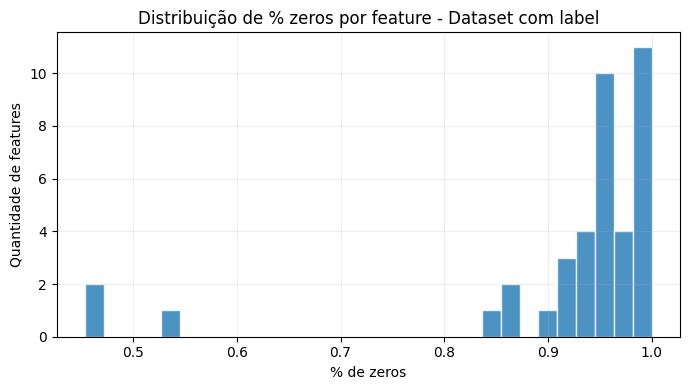


===== Esparsidade | Dataset sem label =====
Features avaliadas: 39
Mediana de zeros por feature: 0.9321
Features com >95% zeros: 43.59%
Features com >99% zeros: 10.26%


,pct_zero,pct_na,pct_nonzero
pneumatose_hoje,0.999217,0.997929,0.000783
pneumatose_passado,0.998925,0.996734,0.001075
pneumatose_futuro,0.998872,0.996840,0.001128
perfuracao_futuro,0.991052,0.989645,0.008948
perfuracao_hoje,0.988410,0.987189,0.011590
hipertermia_hoje,0.983007,0.516655,0.016993
perfuracao_passado,0.981586,0.979820,0.018414
hipertermia_passado,0.980404,0.555528,0.019596
hipertermia_futuro,0.980112,0.523001,0.019888
bradicardia_hoje,0.977046,0.974603,0.022954


,pct_zero,pct_na,pct_nonzero
distensao_abdominal_hoje,0.443371,0.436613,0.556629
distensao_abdominal_passado,0.459700,0.455930,0.540300
distensao_abdominal_futuro,0.510455,0.504428,0.489545
desc_respirat_passado,0.805544,0.764547,0.194456
desc_respirat_hoje,0.822591,0.783439,0.177409
desc_respirat_futuro,0.827848,0.791113,0.172152
apneia_passado,0.858357,0.853484,0.141643
apneia_hoje,0.876691,0.872204,0.123309
hipocorado_futuro,0.881165,0.881165,0.118835
hipocorado_passado,0.882652,0.882652,0.117348


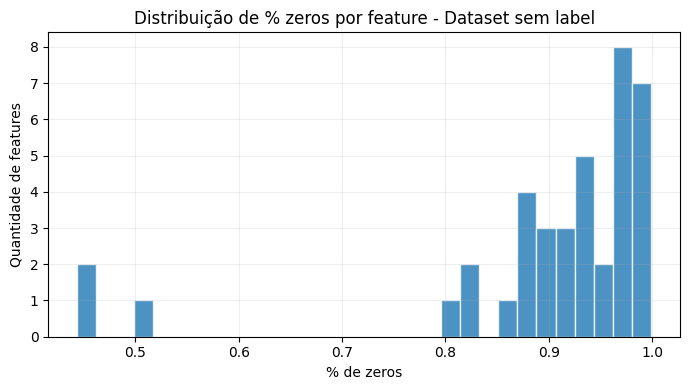

TypeError: 'NoneType' object is not subscriptable

In [9]:
def resumo_esparsidade(base, nome_base):
    base_num = base.select_dtypes(include=[np.number]).copy()
    if base_num.empty:
        print(f"[{nome_base}] Sem colunas numéricas para diagnóstico.")
        return None

    p_zero = (base_num.fillna(0) == 0).mean()
    p_na = base_num.isna().mean()
    p_nonzero = (base_num.fillna(0) != 0).mean()

    resumo = pd.DataFrame({
        "pct_zero": p_zero,
        "pct_na": p_na,
        "pct_nonzero": p_nonzero,
    }).sort_values("pct_zero", ascending=False)

    print(f"\n===== Esparsidade | {nome_base} =====")
    print(f"Features avaliadas: {resumo.shape[0]}")
    print(f"Mediana de zeros por feature: {resumo['pct_zero'].median():.4f}")
    print(f"Features com >95% zeros: {(resumo['pct_zero'] > 0.95).mean():.2%}")
    print(f"Features com >99% zeros: {(resumo['pct_zero'] > 0.99).mean():.2%}")
    display(resumo.head(15))
    display(resumo.sort_values('pct_zero').head(15))

    plt.figure(figsize=(7, 4))
    plt.hist(resumo['pct_zero'], bins=30, alpha=0.8, edgecolor='white')
    plt.title(f"Distribuição de % zeros por feature - {nome_base}")
    plt.xlabel("% de zeros")
    plt.ylabel("Quantidade de features")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    return resumo

def comparar_nonzero_por_grupo(base, grupos, nome_grupo, top_features):
    aux = base[top_features].copy()
    aux['__grp__'] = grupos.values if hasattr(grupos, 'values') else grupos
    aux = aux.dropna(subset=['__grp__'])

    labels = sorted(aux['__grp__'].unique())
    if len(labels) < 2:
        print(f"[{nome_grupo}] Menos de 2 grupos para comparação.")
        return None

    saida = []
    for feat in top_features:
        linha = {'criterio': feat}
        for g in labels:
            mask = aux['__grp__'] == g
            linha[f'nonzero_grupo_{g}'] = (aux.loc[mask, feat].fillna(0) != 0).mean()
        if len(labels) == 2:
            g0, g1 = labels[0], labels[1]
            denom = linha[f'nonzero_grupo_{g0}'] + 1e-9
            linha['lift_g1_vs_g0'] = linha[f'nonzero_grupo_{g1}'] / denom
        saida.append(linha)

    tab = pd.DataFrame(saida).sort_values('lift_g1_vs_g0', ascending=False) if len(labels) == 2 else pd.DataFrame(saida)
    print(f"\n===== Taxa de não-zero por {nome_grupo} =====")
    display(tab)
    return tab

# 1) Diagnóstico global de esparsidade
esp_com_label = resumo_esparsidade(X_crit_com_label, "Dataset com label")
esp_sem_label = resumo_esparsidade(X_crit_sem_label, "Dataset sem label")

# 2) Relação com label real: olhar top critérios e sua presença por classe
top_label = res_rel_com_label['tabela']['criterio'].head(12).tolist()
print("\nTop critérios (label real):", top_label)
tab_label = comparar_nonzero_por_grupo(
    X_crit_com_label,
    df.loc[X_crit_com_label.index, 'caso infeccao'].astype(str),
    "classe da label real",
    top_label,
)

# 3) Sem label: olhar top critérios da pseudo-label e presença por cluster
top_pseudo = res_rel_sem_label['tabela']['criterio'].head(12).tolist()
print("\nTop critérios (pseudo-label):", top_pseudo)
tab_pseudo = comparar_nonzero_por_grupo(
    X_crit_sem_label,
    pd.Series(res_rel_sem_label['y_cluster'], index=res_rel_sem_label['base_limpa'].index).reindex(X_crit_sem_label.index).fillna(-1).astype(int),
    "cluster (pseudo-label)",
    top_pseudo,
 )

print("\nResumo: se pct_zero estiver muito alto na maioria das features, os histogramas naturalmente ficam concentrados em zero.")


===== Demais features (sem critérios) | Dataset sem label =====
Total de colunas no dataset: 206
Colunas de critérios removidas: 39
Demais colunas analisadas: 167

Top colunas com mais faltantes:


,feature,dtype,qtd_missing,pct_missing,n_unique
29,FIO2_min,float64,72625,0.964181,72
30,FIO2_max,float64,72625,0.964181,68
119,neuto_min,float64,71204,0.945316,3339
120,neuto_max,float64,71204,0.945316,3342
121,neuto_avg,float64,71204,0.945316,3358
113,leuco_min,float64,71203,0.945302,2592
114,leuco_max,float64,71203,0.945302,2594
115,leuco_avg,float64,71203,0.945302,2618
116,rdw_min,float64,71203,0.945302,163
117,rdw_max,float64,71203,0.945302,163



Resumo de faltantes (%):
count    167.000000
mean       0.157340
std        0.321930
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
90%        0.906549
95%        0.945302
99%        0.951730
max        0.964181

Numéricas em 'demais features': 164
Numéricas variáveis (para correlação): 150

Top pares mais correlacionados (|Spearman|):


,feature_1,feature_2,corr_abs_spearman
605,CIRURGIA_tempo_total,CIRURGIA_procedimentos_total,0.999971
14951,rdw_min,rdw_avg,0.999741
15101,rdw_max,rdw_avg,0.999711
15554,neuto_max,neuto_avg,0.999114
14950,rdw_min,rdw_max,0.998963
15404,neuto_min,neuto_avg,0.998315
14648,leuco_max,leuco_avg,0.998217
14498,leuco_min,leuco_avg,0.997271
15403,neuto_min,neuto_max,0.995132
14497,leuco_min,leuco_max,0.991472


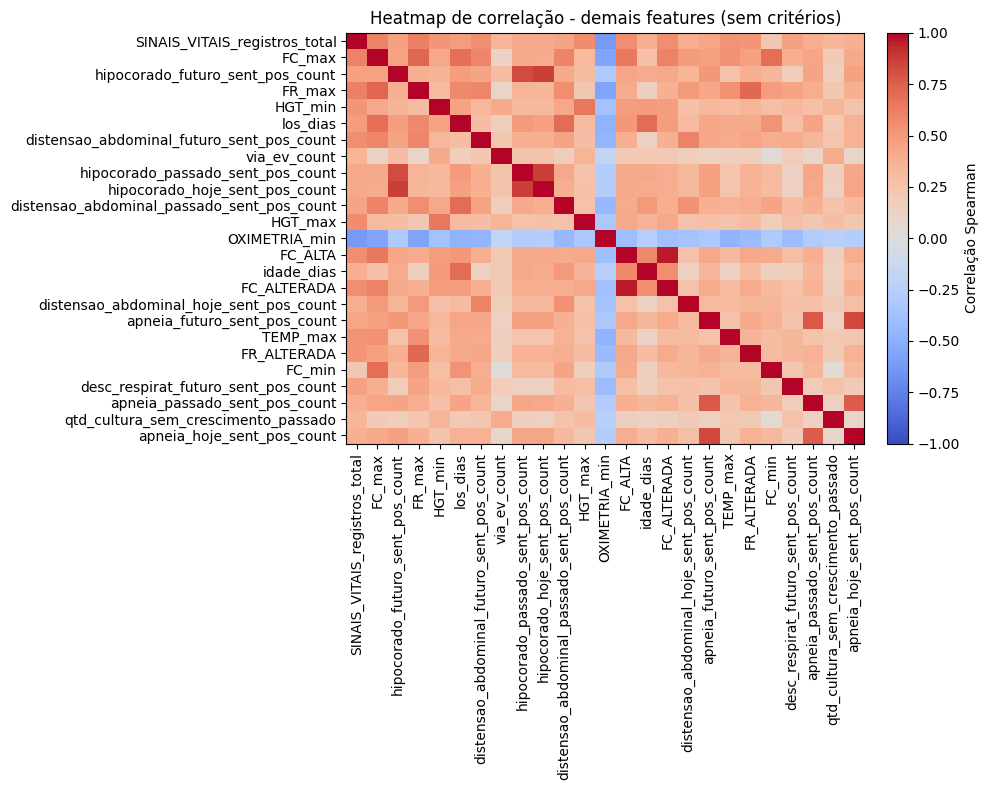

In [ ]:
def analisar_demais_features_sem_label(df_base, criterios_lista, top_n_missing=30, top_n_corr_pairs=30, top_n_heatmap=25):
    # 1) Seleciona somente features fora da lista de critérios
    cols_demais = [c for c in df_base.columns if c not in criterios_lista]
    df_demais = df_base[cols_demais].copy()

    print("\n===== Demais features (sem critérios) | Dataset sem label =====")
    print(f"Total de colunas no dataset: {df_base.shape[1]}")
    print(f"Colunas de critérios removidas: {len([c for c in criterios_lista if c in df_base.columns])}")
    print(f"Demais colunas analisadas: {df_demais.shape[1]}")

    # 2) Faltantes para todas as colunas
    faltantes = pd.DataFrame({
        "feature": df_demais.columns,
        "dtype": df_demais.dtypes.astype(str).values,
        "qtd_missing": df_demais.isna().sum().values,
        "pct_missing": df_demais.isna().mean().values,
        "n_unique": [df_demais[c].nunique(dropna=True) for c in df_demais.columns],
    }).sort_values(["pct_missing", "qtd_missing"], ascending=False)

    print("\nTop colunas com mais faltantes:")
    display(faltantes.head(top_n_missing))

    print("\nResumo de faltantes (%):")
    print(faltantes["pct_missing"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_string())

    # 3) Correlação para colunas numéricas variáveis
    df_num = df_demais.select_dtypes(include=[np.number]).copy()
    nunique_num = df_num.nunique(dropna=False)
    df_num_var = df_num.loc[:, nunique_num > 1]

    print(f"\nNuméricas em 'demais features': {df_num.shape[1]}")
    print(f"Numéricas variáveis (para correlação): {df_num_var.shape[1]}")

    if df_num_var.shape[1] < 2:
        print("Poucas colunas numéricas variáveis para calcular correlação.")
        return {"faltantes": faltantes, "corr_pairs": None, "corr_matrix": None}

    corr = df_num_var.corr(method="spearman")
    corr_abs = corr.abs()

    # Extrai pares com maior correlação absoluta (exclui diagonal e duplicatas)
    pares = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool)).stack().reset_index()
    pares.columns = ["feature_1", "feature_2", "corr_abs_spearman"]
    pares = pares.sort_values("corr_abs_spearman", ascending=False)

    print("\nTop pares mais correlacionados (|Spearman|):")
    display(pares.head(top_n_corr_pairs))

    # Heatmap reduzido: seleciona features com maior correlação média absoluta
    media_abs = (corr_abs.sum() - 1) / (corr_abs.shape[0] - 1)
    feats_heatmap = media_abs.sort_values(ascending=False).head(min(top_n_heatmap, len(media_abs))).index.tolist()
    corr_heatmap = corr.loc[feats_heatmap, feats_heatmap]

    plt.figure(figsize=(10, 8))
    im = plt.imshow(corr_heatmap.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04, label="Correlação Spearman")
    plt.xticks(range(len(feats_heatmap)), feats_heatmap, rotation=90)
    plt.yticks(range(len(feats_heatmap)), feats_heatmap)
    plt.title("Heatmap de correlação - demais features (sem critérios)")
    plt.tight_layout()
    plt.show()

    return {"faltantes": faltantes, "corr_pairs": pares, "corr_matrix": corr}

resultado_demais_sem_criterios = analisar_demais_features_sem_label(
    df_base=df_no_label,
    criterios_lista=criterios,
    top_n_missing=30,
    top_n_corr_pairs=30,
    top_n_heatmap=25,
 )